# Manual Gating for Replicates and MgkPros.

## Prepare Notebook.

### Import Libraries.

In [1]:
import logging
import os
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

### Add Extra Environment Variables.

In [2]:
sys.path.insert(0, "../../shared_utils")
from data_utils import sanitize_anndata
from experiment_utils import get_forward_model
from plot_utils import make_scatter_plot

### Setup Logger.

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] - %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)


### Load Hydra Configurations.

In [4]:
with hydra.initialize(
    config_path="../../inverse/loss_guidance/config",
    version_base=None
):
    config = hydra.compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus"
        ]
    )
scatter_cols = config.annotation.scatter_columns

## Read Data.

### Load Loop 2 Data from Disk.

In [5]:
h5ad_loop2_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad"
adata_loop2 = sc.read_h5ad(h5ad_loop2_path)
adata_loop2


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Compute Neighbors Graph and UMAP for Loop 2 Data.

In [6]:
sc.pp.neighbors(adata_loop2)
sc.tl.umap(adata_loop2)
adata_loop2


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap'
    obsm: 'X_u

### Read Data from Loop 1.

In [7]:
h5ad_loop1_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad"
adata_loop1 = sc.read_h5ad(h5ad_loop1_path)
adata_loop1


AnnData object with n_obs × n_vars = 499956 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Data Loop 3.

In [50]:
h5ad_loop3_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad"
adata_loop3 = sc.read_h5ad(h5ad_loop3_path)
adata_loop3


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Compute Neighbors Graph and UMAP for Loop 3 Data.

In [51]:
sc.pp.neighbors(adata_loop3)
sc.tl.umap(adata_loop3)
adata_loop3


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap'
    obsm: 'X_u

## Propagate Cell Type Labels to New Data with Classifier.

### Load Model.

In [8]:
forward_model, (
    pert_resp_prediction_model,
    target_prediction_model
) = get_forward_model(config, logger=logger)
target_prediction_model.target_prediction_model.eval()


[2026-06-25 11:45:12] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
[2026-06-25 11:47:15] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
 

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

### Get Standardization Parameters.

In [9]:
train_adata_g = target_prediction_model.train_data.adata
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params = train_adata_g.uns["X_scatter_params"]


### Fit Label Encoder.

In [10]:
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


### Prepare Data for Prediction Model.

In [52]:
# ---- Get original features ----
X_channel = adata_loop3.X
X_scatter = adata_loop3.obs[scatter_cols].astype(float).values

# ---- Standardize features ----
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

# ---- Concatenate standardized features ----
X = np.concatenate((X_channel, X_scatter), axis=1)
X_torch = torch.from_numpy(X).to(torch.float32)
print(f"{X_channel.shape=}, {X_channel.shape=}, {X.shape=}")


X_channel.shape=(499996, 20), X_channel.shape=(499996, 20), X.shape=(499996, 26)


### Prepare DataLoader for Classifier.

In [54]:
dataset = TensorDataset(X_torch)
dataloader = DataLoader(dataset, batch_size=10_000, shuffle=False)


### Classify Data.

In [55]:
# ---- List to store the predictions ----
ct_preds = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader):
        xb = xb[0]
        xb = xb.to(target_prediction_model.device)
        y_pred = target_prediction_model.predict(xb)["cell_type"].argmax(1)
        ct_preds.append(y_pred.cpu().detach().numpy())
ct_preds = np.concatenate(ct_preds)

# ---- Decode predicted cell types ----
ct_preds = classes[ct_preds]

# ---- Write back to anndata ----
adata_loop3.obs["cell_type"] = ct_preds
adata_loop3

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:10<00:00,  4.65it/s]


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap'
 

### Visualize Predicted Cell Types.

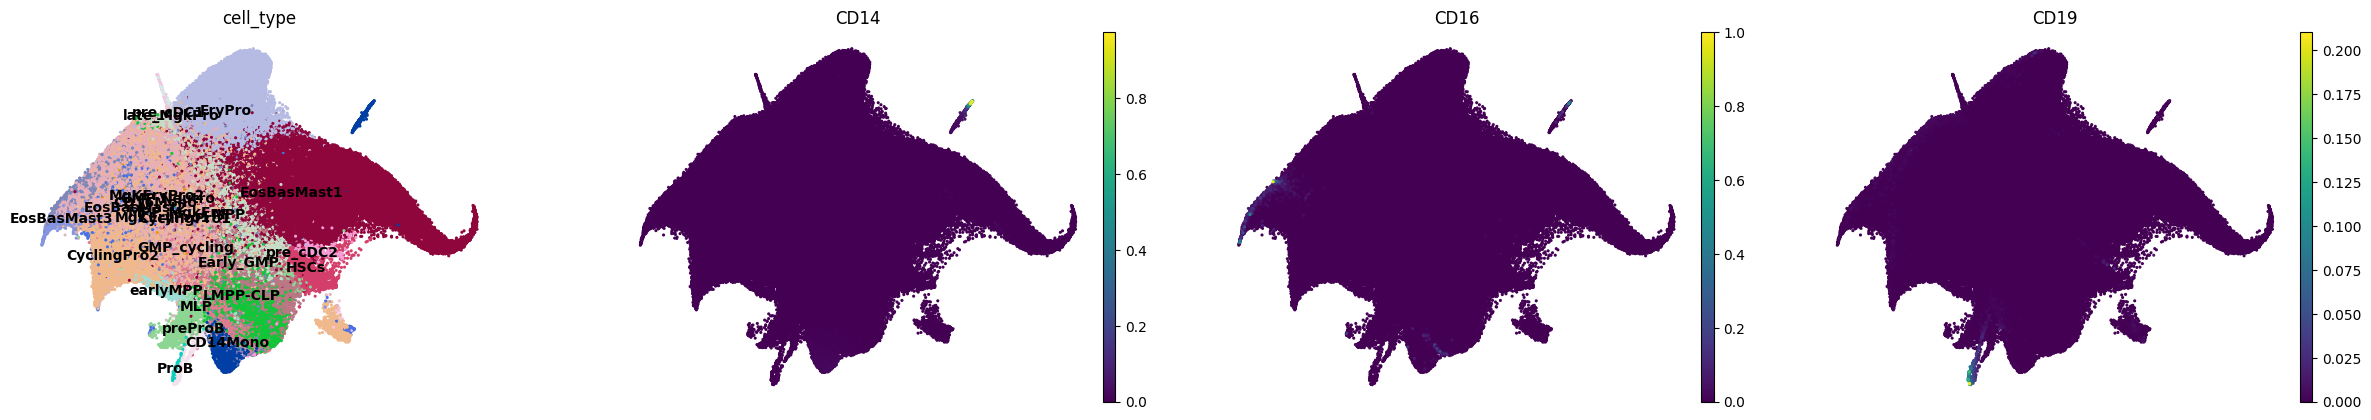

In [59]:
dc1_markers = ["EPCR", "CD49c", "CD14", "CD7", "CD15", "CD38"]
mgk_markers = ["CD41a"]
hsc_markers = ["CD34", "CD90", "EPCR"]
cd14_markers = ["CD14"]
cd16_markers = ["CD16"]
prob_markers = ["CD19"]

# sc.pl.embedding(adata_loop3, "umap", color=["cell_type"] + dc1_markers + mgk_markers + hsc_markers + cd14_markers + cd16_markers, frameon=False, legend_loc="on data", s=20)
sc.pl.embedding(adata_loop3, "umap", color=["cell_type"] + cd14_markers + cd16_markers + prob_markers, frameon=False, legend_loc="on data", s=20)


### Plot each Cell Type Individually

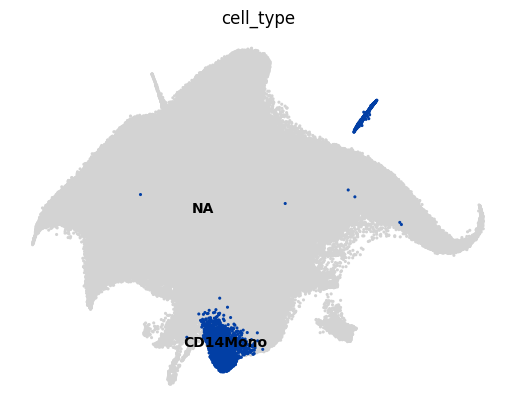

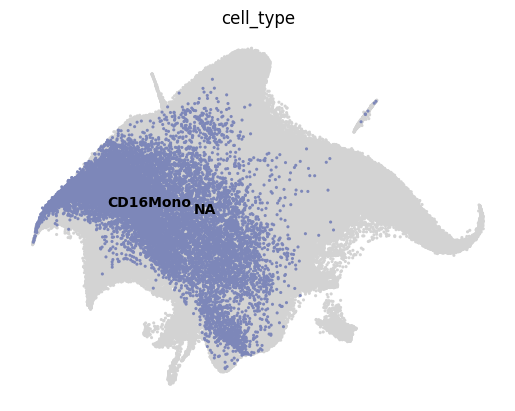

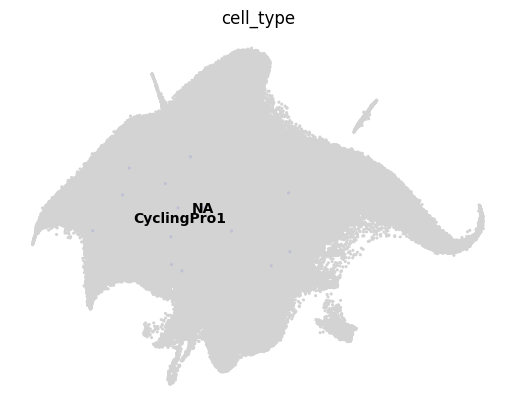

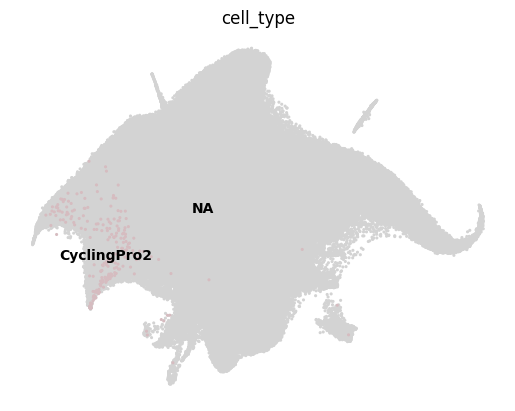

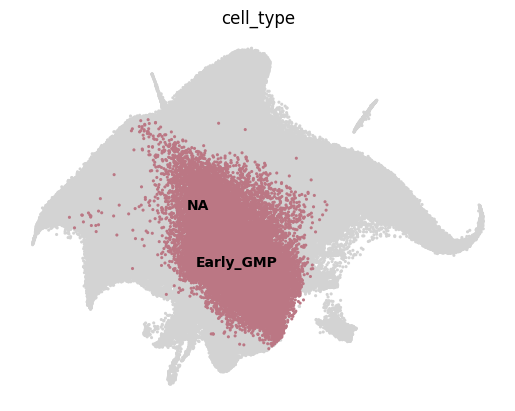

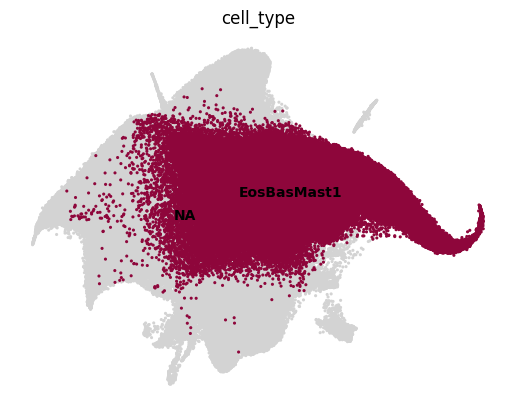

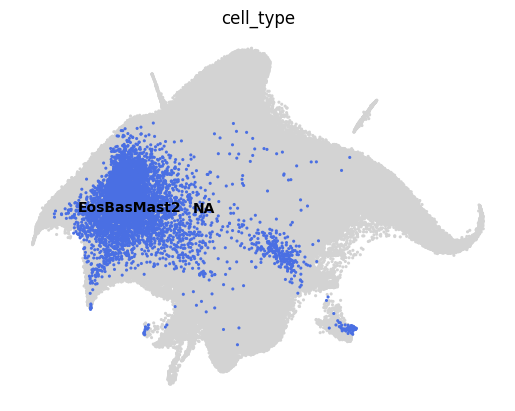

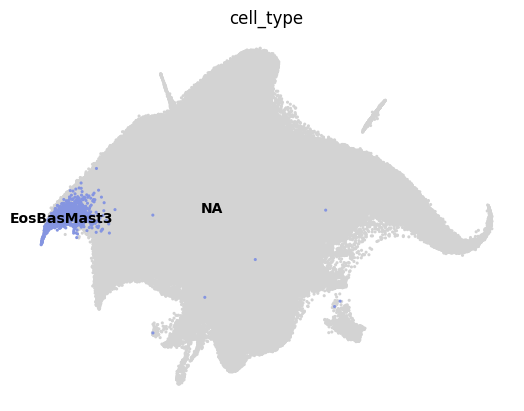

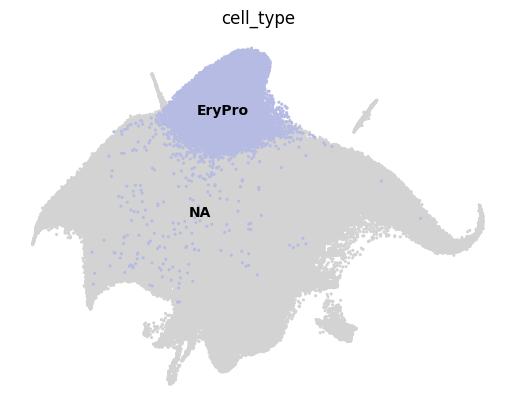

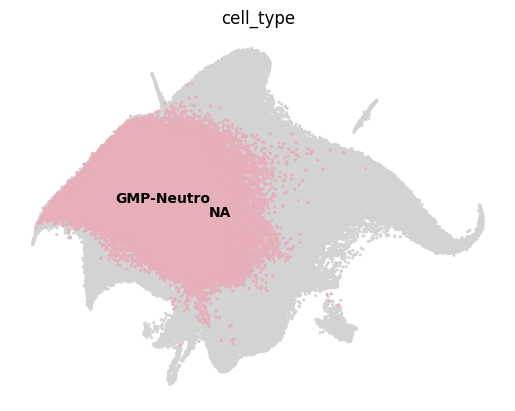

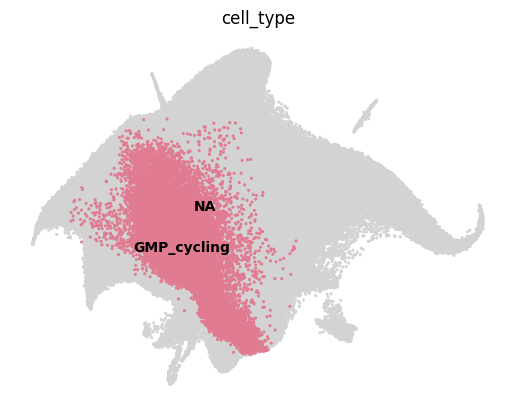

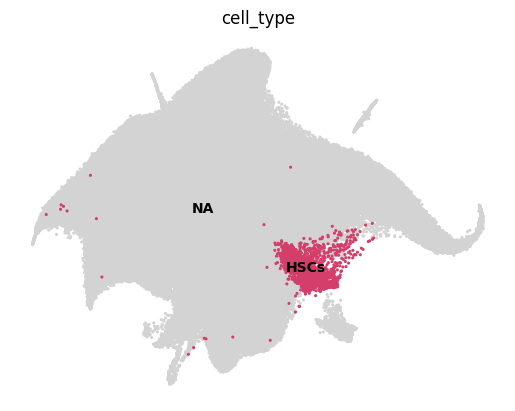

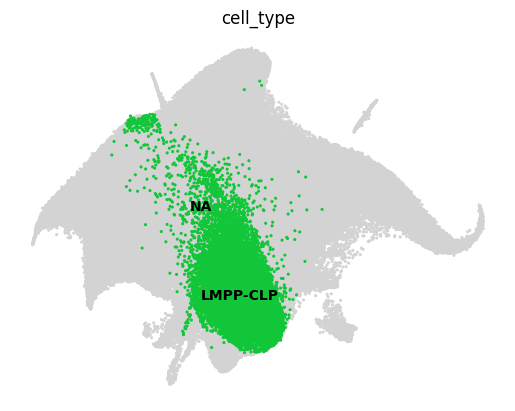

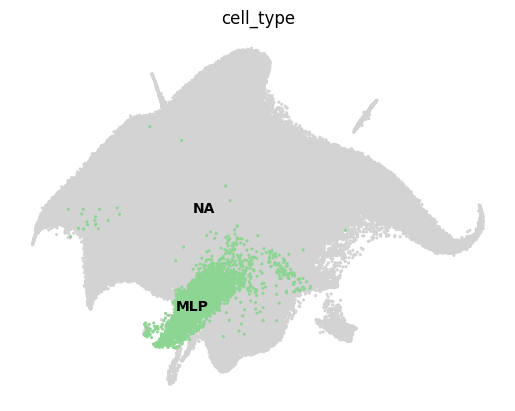

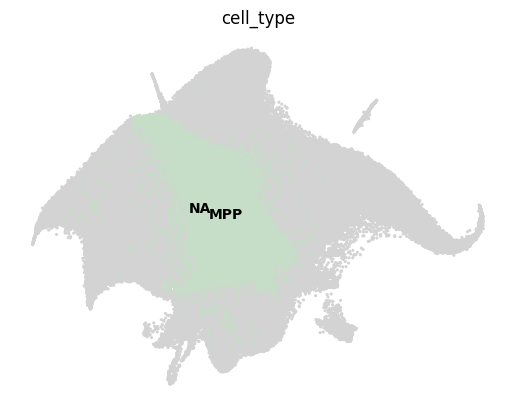

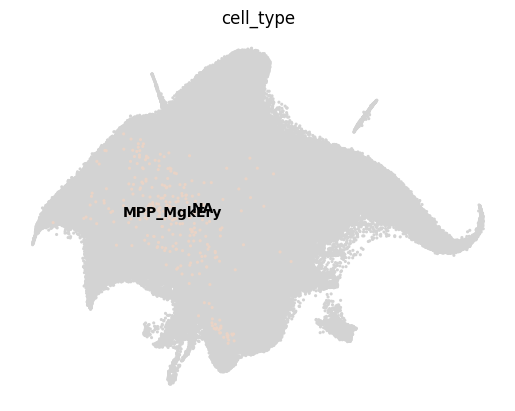

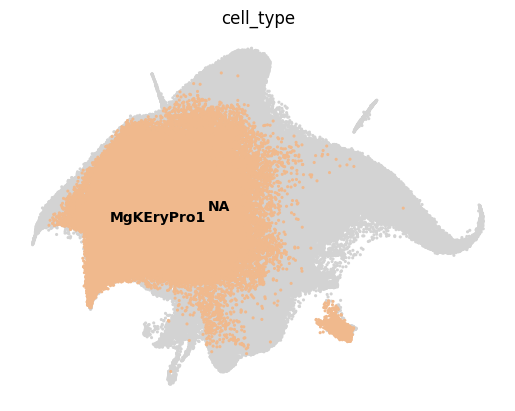

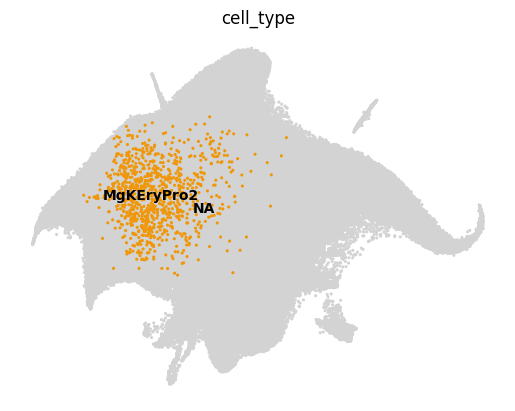

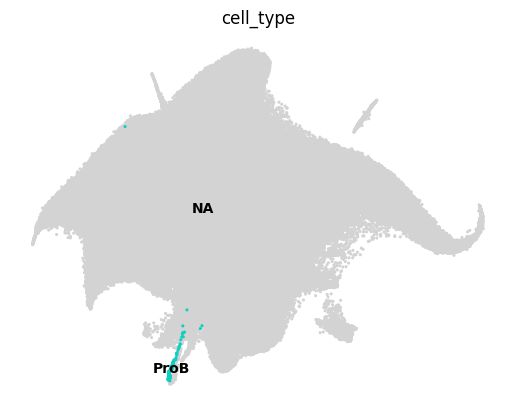

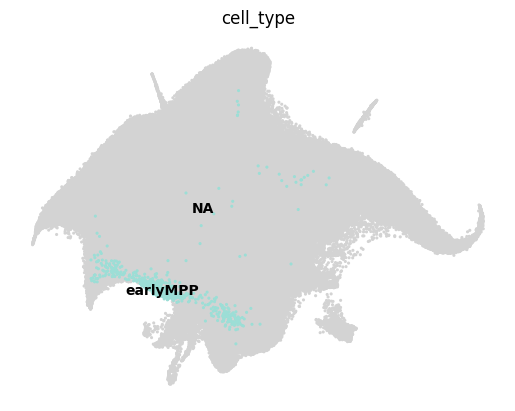

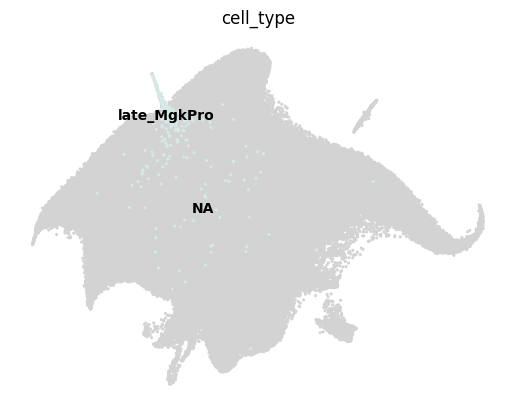

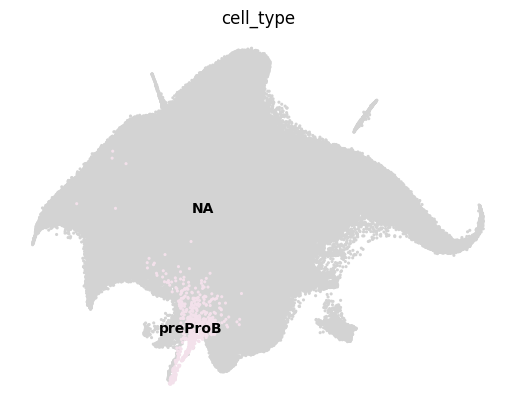

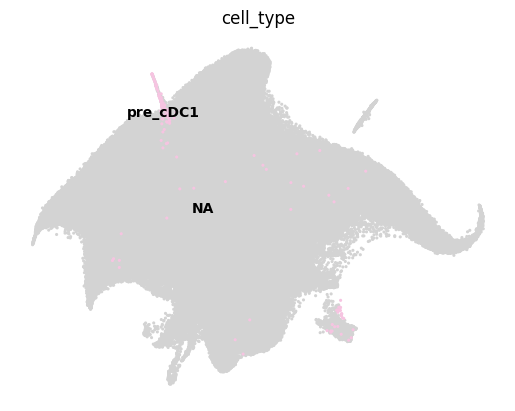

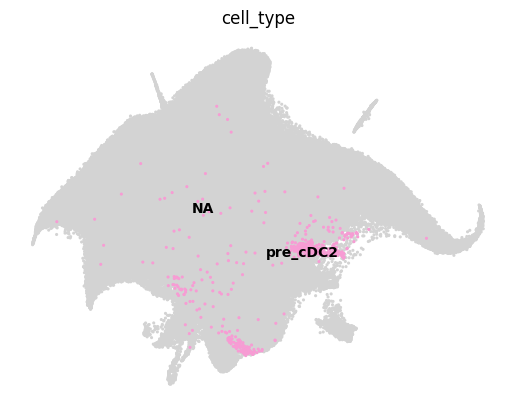

In [57]:
for ct in classes:
    sc.pl.embedding(adata_loop3, "umap", color=["cell_type"], groups=[ct], frameon=False, legend_loc="on data", s=20)


# Monocytes.

## Get Pre CD14 Population from Loop 1.

### Subset Adata.

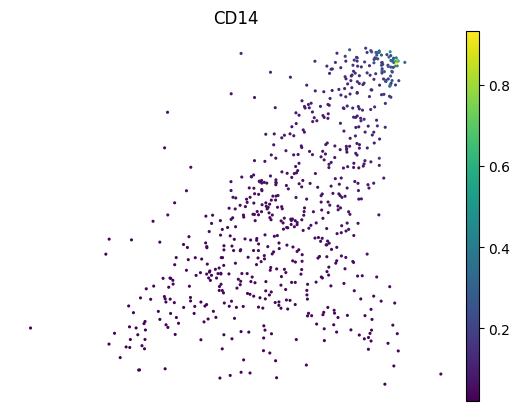

AnnData object with n_obs × n_vars = 667 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type', 'leiden_HSCs', 'cell_type_reannot', 'is_cDC1_reannot', 'cell_type_reannot_final', 'is_HSCs_reannot', 'leiden_cDC1'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'Pn

In [61]:
cd14_mask_loop1 = adata_loop1.obs["cell_type"] == "CD14Mono"
adata_cd14_loop1 = adata_loop1[cd14_mask_loop1].copy()
sc.pl.embedding(adata_cd14_loop1, "umap", color=cd14_markers, frameon=False, legend_loc="on data", s=20)
adata_cd14_loop1

### Scatter Plot of Markers.

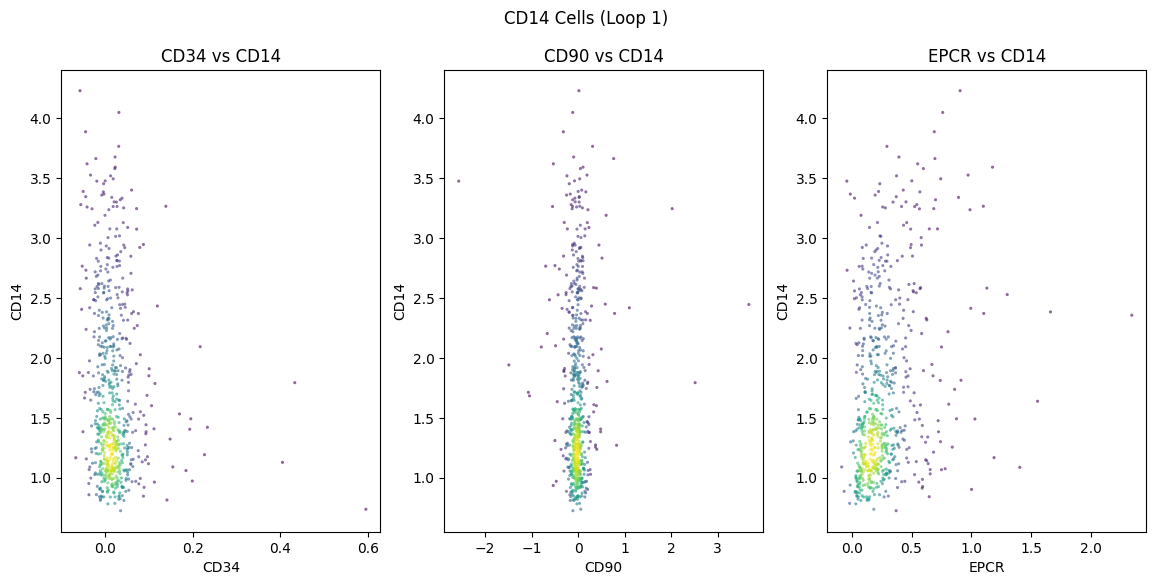

In [68]:
# plot old data
_ = make_scatter_plot(
    adata_cd14_loop1,
    target_markers=cd14_markers,
    ref_markers=hsc_markers,
    title="CD14 Cells (Loop 1)"
)

### Dot Plot of CD14 Cells from Loop 1.

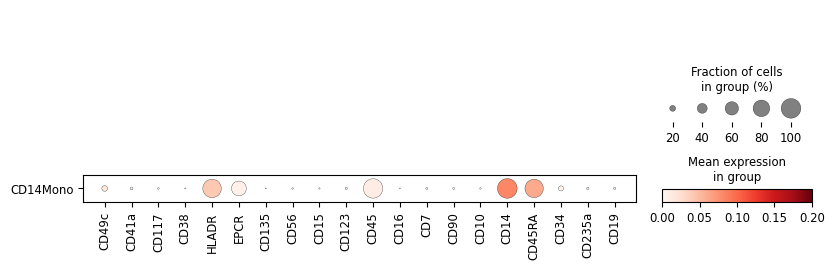

In [69]:
sc.pl.dotplot(
    adata_cd14_loop1,
    adata_cd14_loop1.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

## Get Pre CD14 Population from Loop 2.

### Subset Adata.

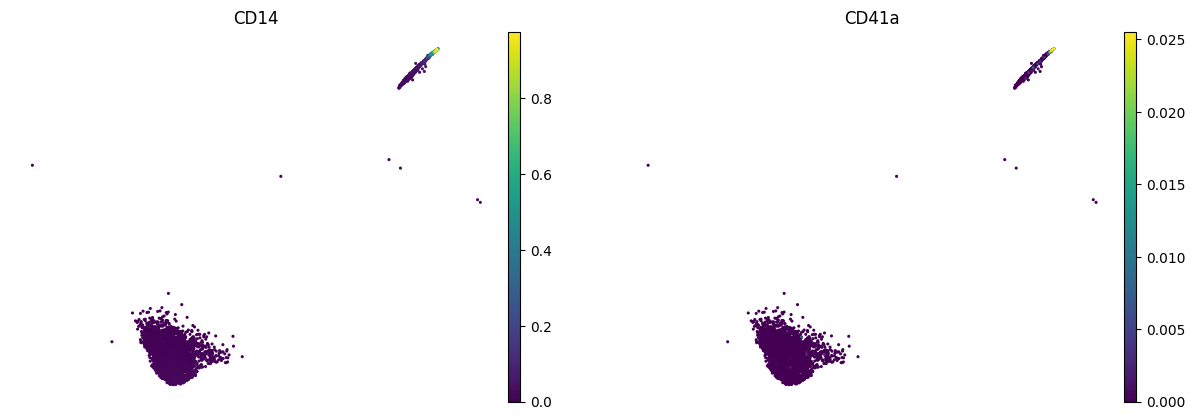

AnnData object with n_obs × n_vars = 3247 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden_cDC1', 'cell_type_reannot', 'is_cDC1_reannot', 'leiden_HSCs', 'cell_type_reannot_final', 'is_HSCs_reannot'
    var: 'n', 'channel', 'marker'

In [75]:
cd14_mask_loop2 = adata_loop2.obs["cell_type"] == "CD14Mono"
adata_cd14_loop2 = adata_loop2[cd14_mask_loop2].copy()
sc.pl.embedding(adata_cd14_loop2, "umap", color=cd14_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_cd14_loop2

### Scatter Plot of Markers.

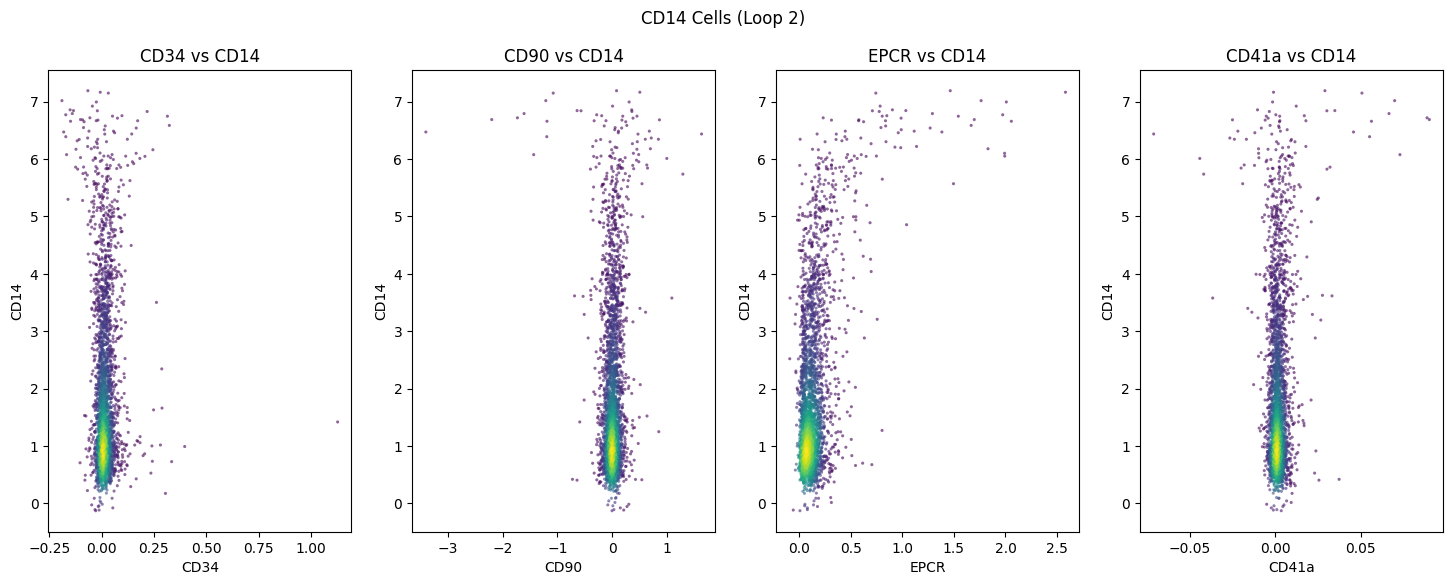

In [72]:
# plot old data
_ = make_scatter_plot(
    adata_cd14_loop2,
    target_markers=cd14_markers,
    ref_markers=hsc_markers + mgk_markers,
    title="CD14 Cells (Loop 2)"
)

### Dot Plot of cDC1 Cells from Loop 2.

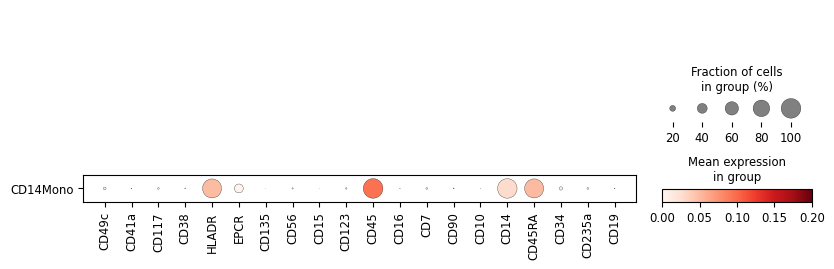

In [73]:
sc.pl.dotplot(
    adata_cd14_loop2,
    adata_cd14_loop2.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

## Get CD14 Population from Loop 3.

### Subset Adata.

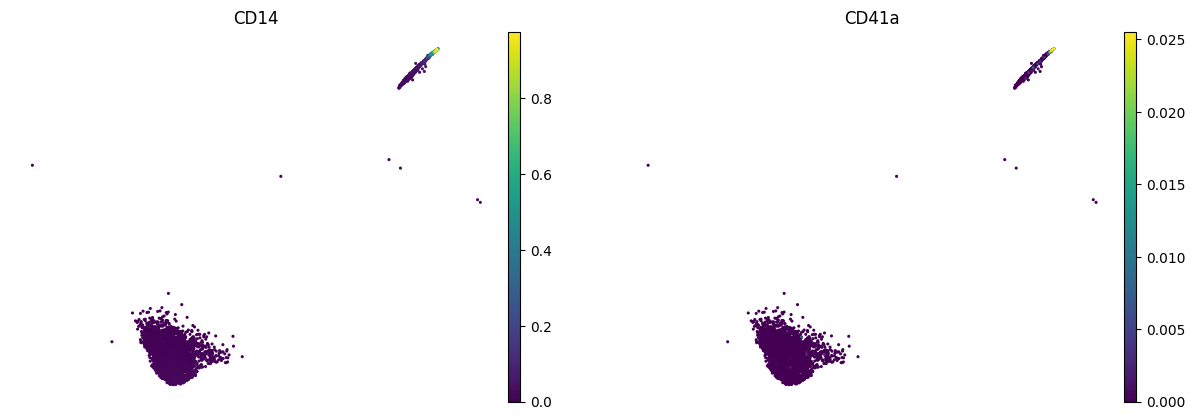

AnnData object with n_obs × n_vars = 3247 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'c

In [76]:
cd14_mask_loop3 = adata_loop3.obs["cell_type"] == "CD14Mono"
adata_cd14_loop3 = adata_loop3[cd14_mask_loop3].copy()
sc.pl.embedding(adata_cd14_loop3, "umap", color=cd14_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_cd14_loop3

### Scatter Plot of Markers.

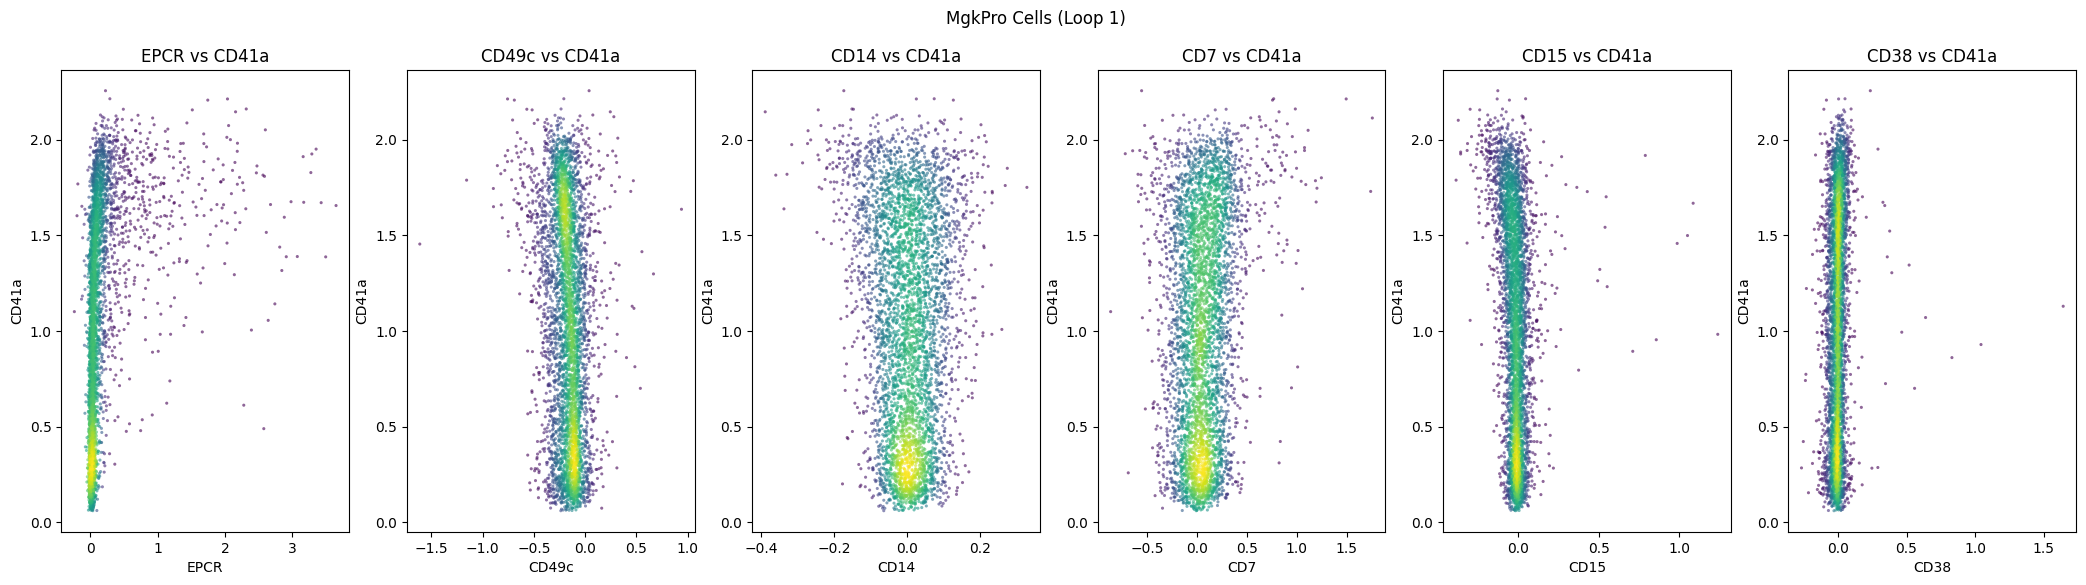

In [23]:
# plot old data
_ = make_scatter_plot(
    adata_mgk_loop1,
    target_markers=mgk_markers,
    ref_markers=dc1_markers,
    title="MgkPro Cells (Loop 1)"
)

### Dotplot.

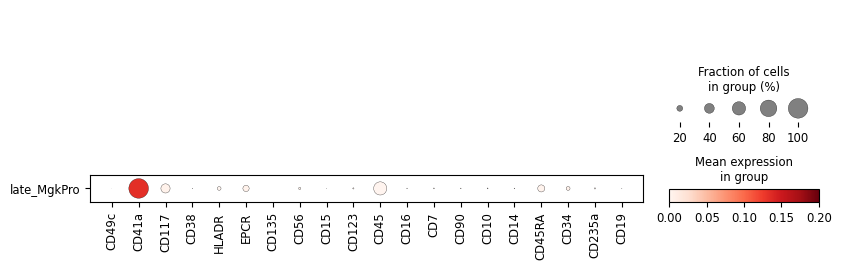

In [24]:
sc.pl.dotplot(
    adata_mgk_loop1,
    adata_mgk_loop1.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

## Get MgkPro Population from Loop 2.

### Subset Adata.

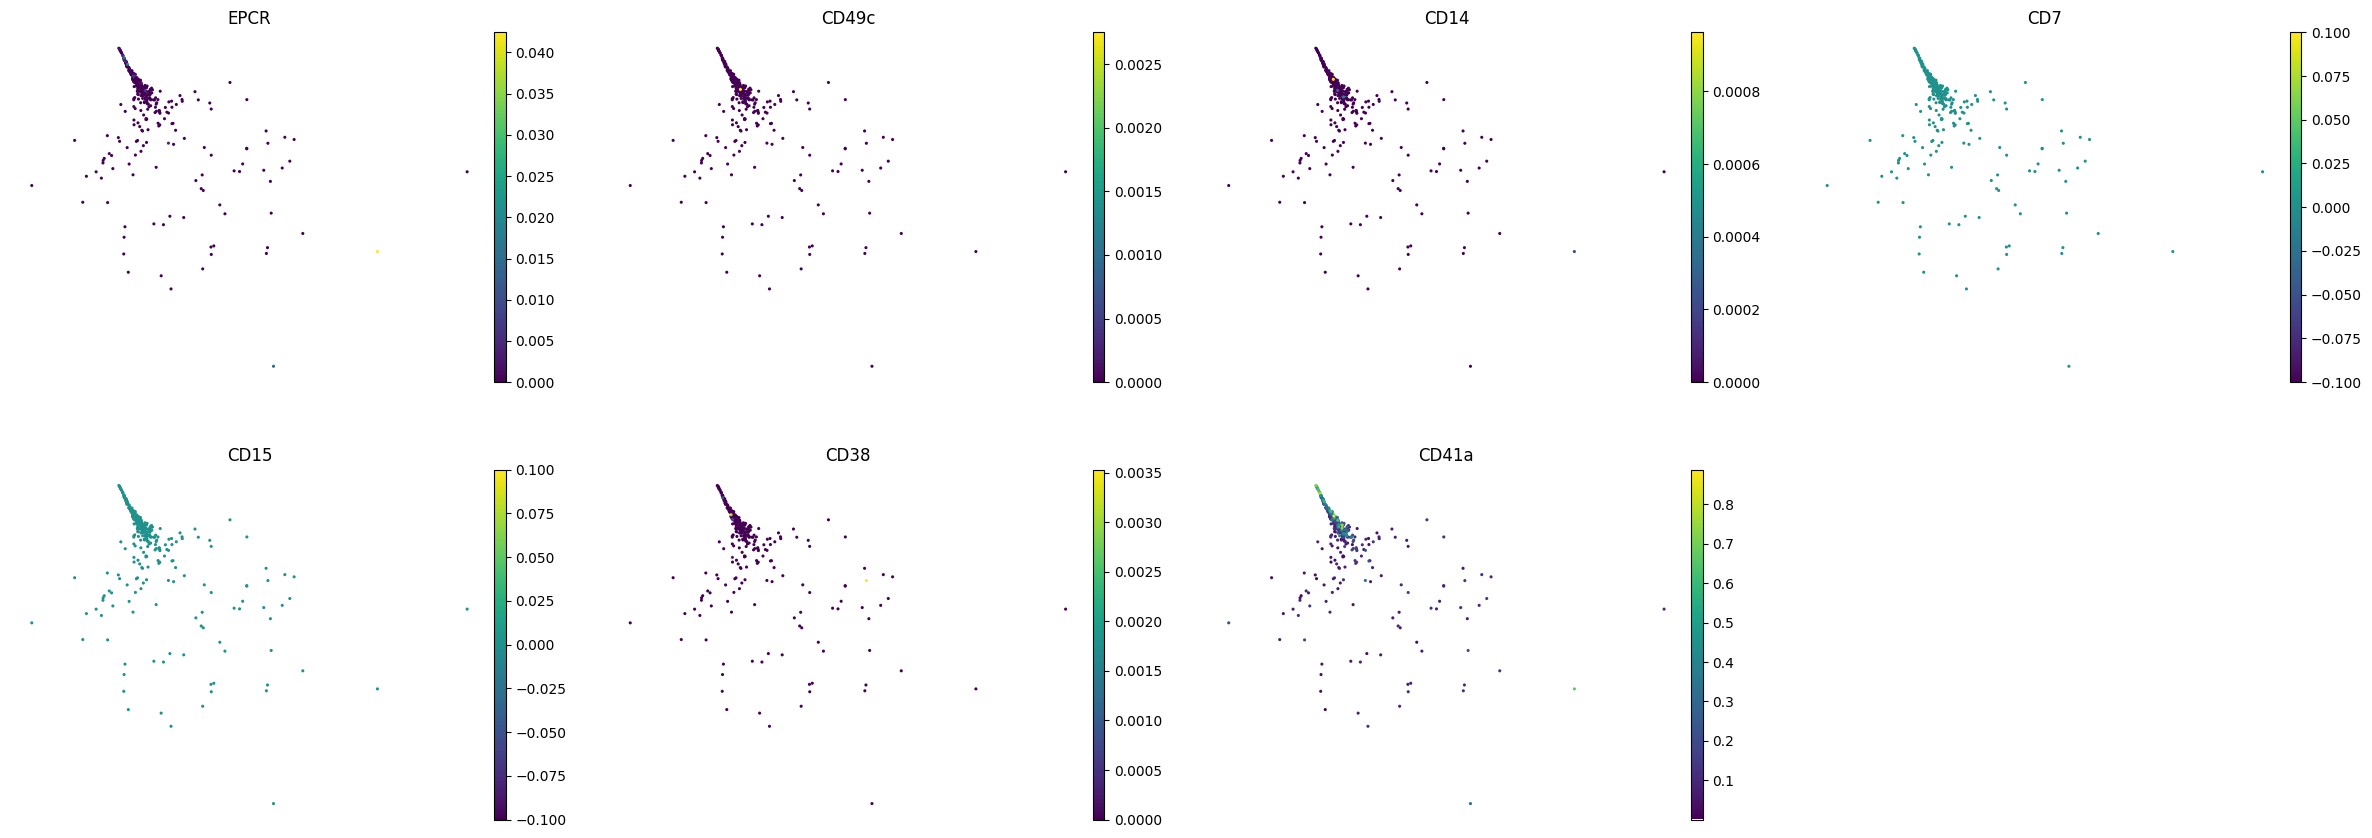

AnnData object with n_obs × n_vars = 304 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'ce

In [25]:
mgk_mask_loop2 = adata_loop2.obs["cell_type"] == "late_MgkPro"
adata_mgk_loop2 = adata_loop2[mgk_mask_loop2].copy()
sc.pl.embedding(adata_mgk_loop2, "umap", color=dc1_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_mgk_loop2

### Scatter Plot of Markers.

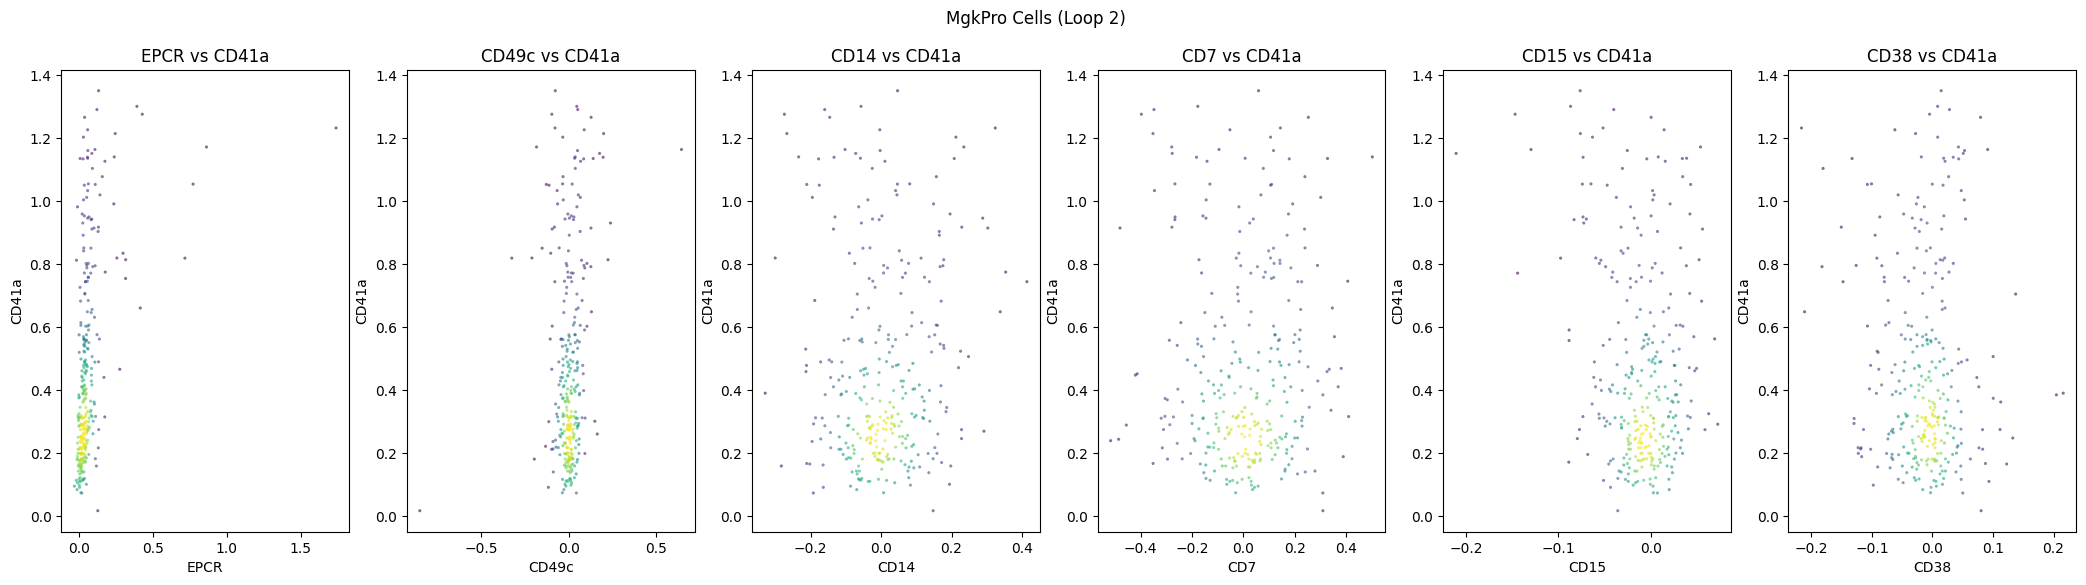

In [26]:
# plot old data
_ = make_scatter_plot(
    adata_mgk_loop2,
    target_markers=mgk_markers,
    ref_markers=dc1_markers,
    title="MgkPro Cells (Loop 2)"
)

### Dotplot.

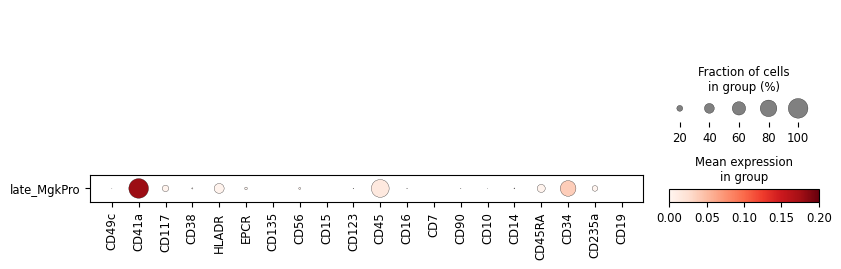

In [27]:
sc.pl.dotplot(
    adata_mgk_loop2,
    adata_mgk_loop2.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

# HSCs.

### Get HSCs from Loop 1 Data.

### Subset Adata.

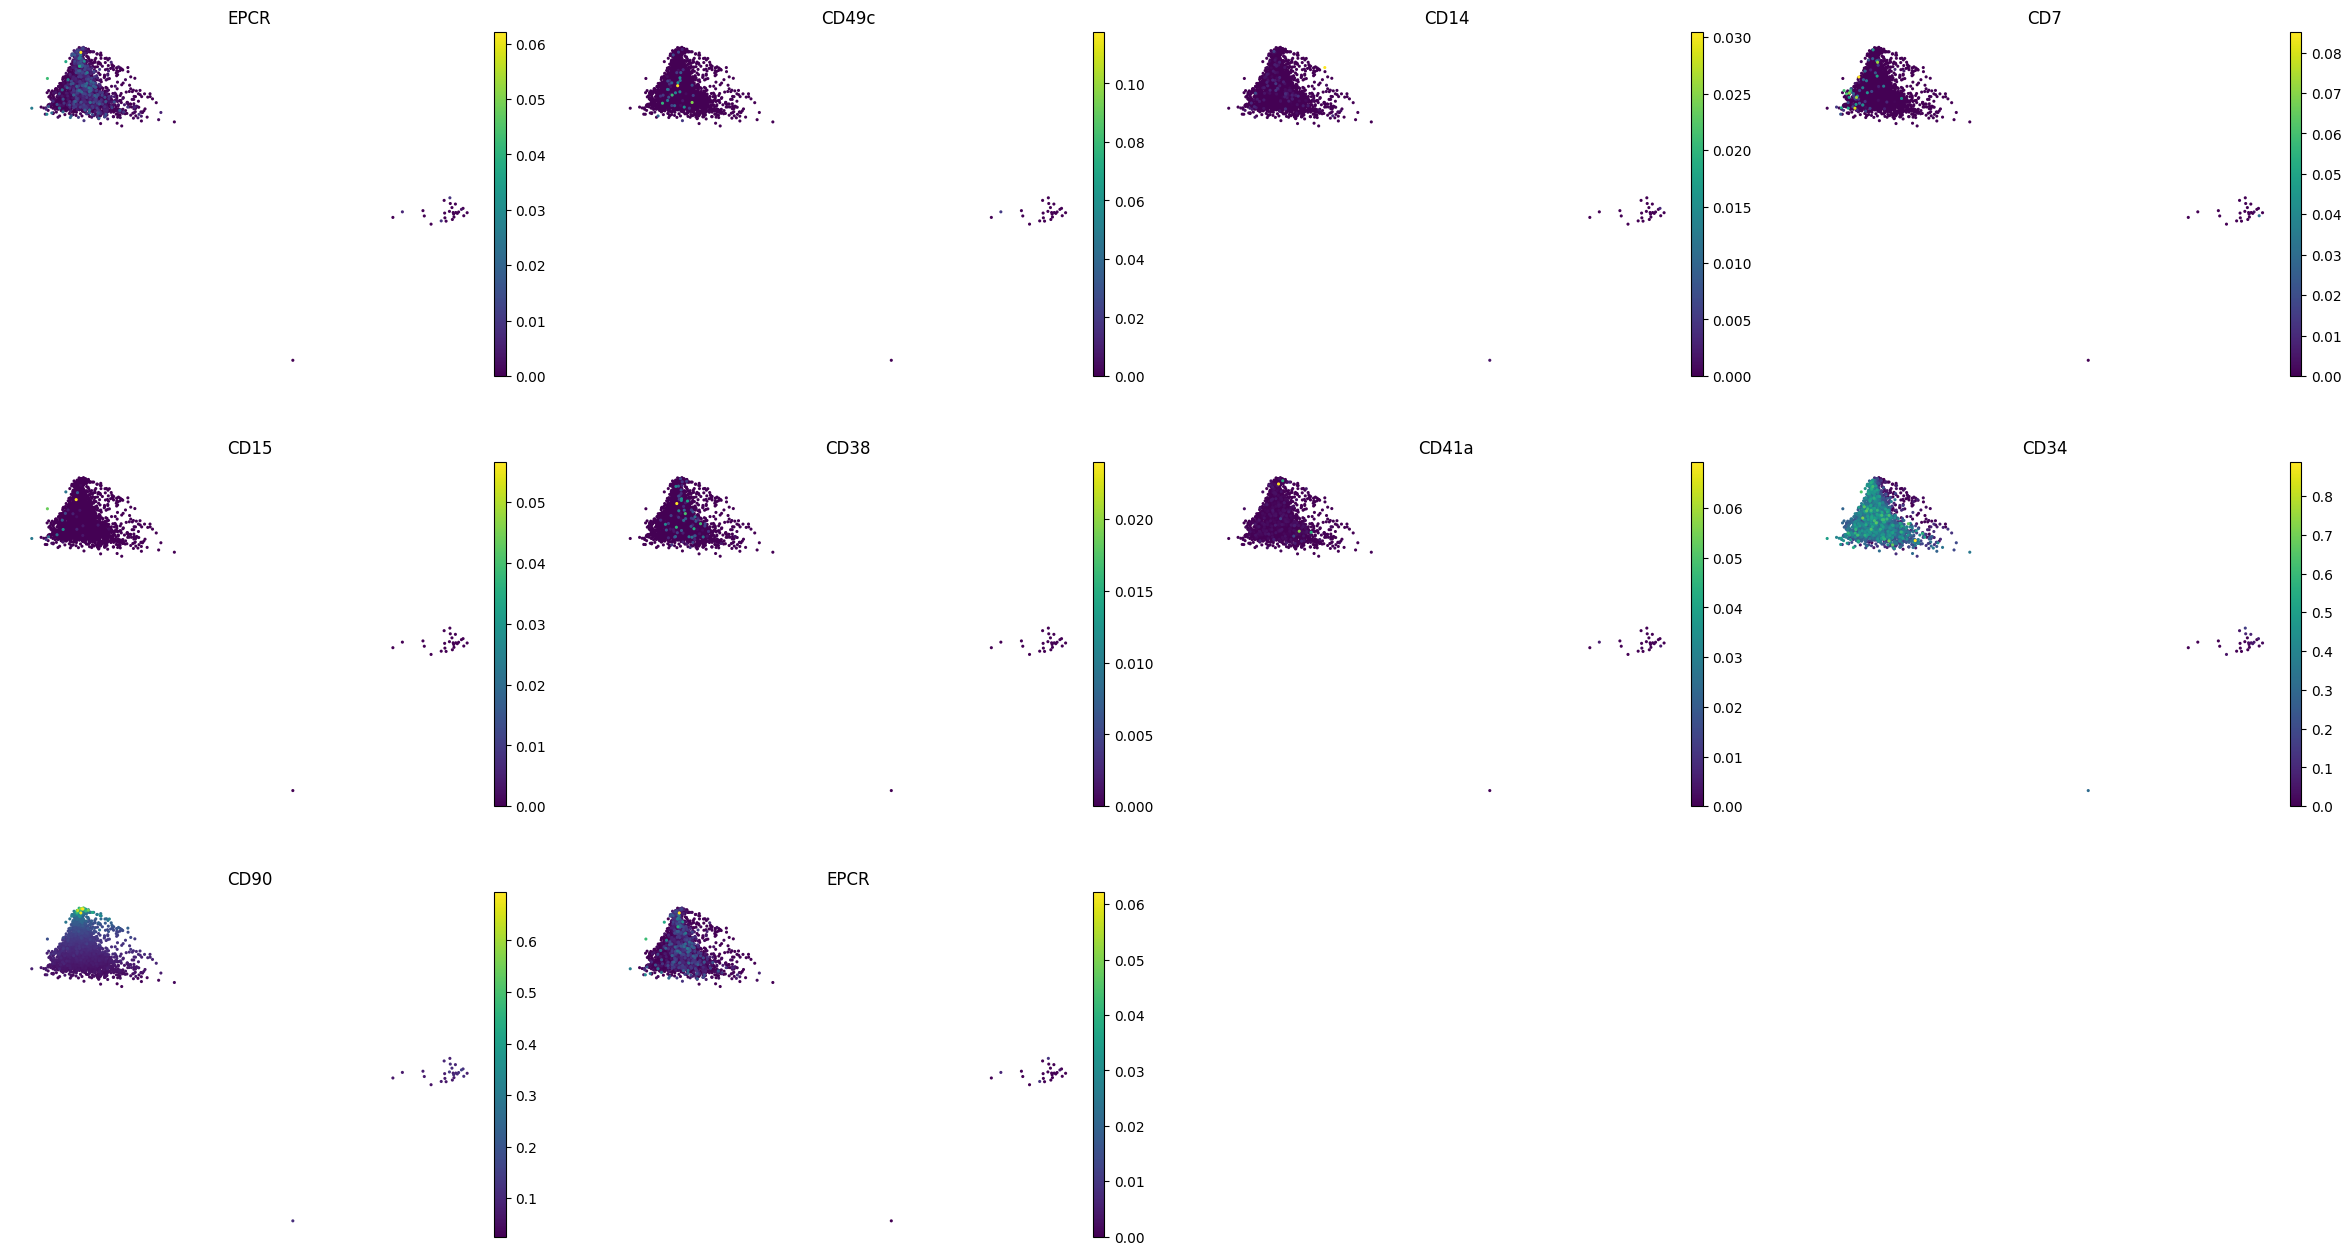

AnnData object with n_obs × n_vars = 2668 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old', '

In [28]:
hsc_mask_loop1 = adata_loop1.obs["cell_type"] == "HSCs"
adata_hsc_loop1 = adata_loop1[hsc_mask_loop1].copy()
sc.pl.embedding(adata_hsc_loop1, "umap", color=dc1_markers + mgk_markers + hsc_markers, frameon=False, legend_loc="on data", s=20)
adata_hsc_loop1

### Scatter Plot of Markers.

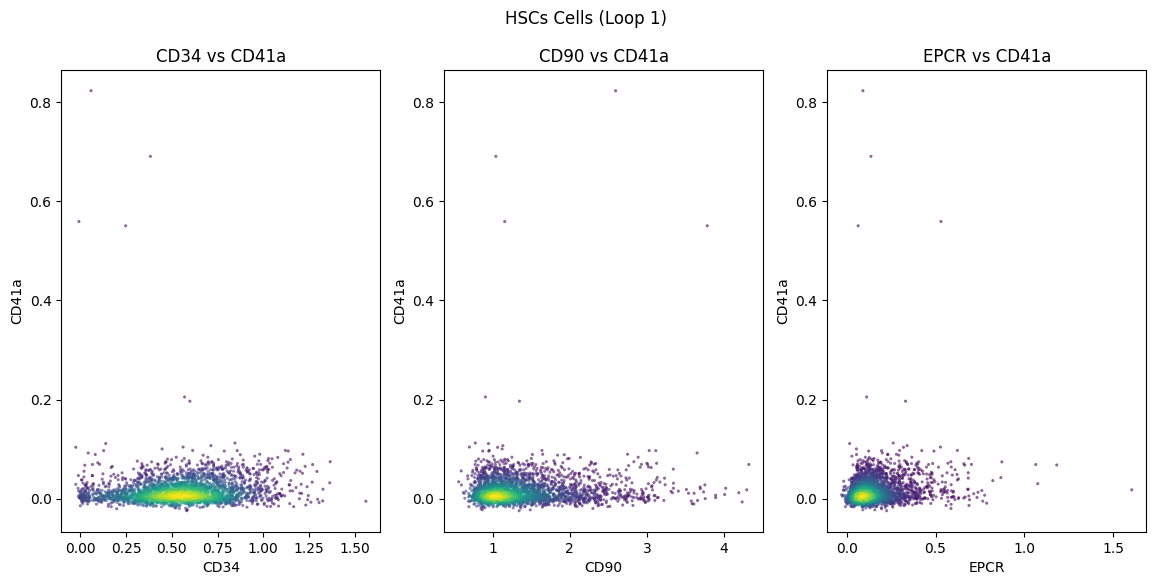

In [29]:
# plot old data
_ = make_scatter_plot(
    adata_hsc_loop1,
    target_markers=mgk_markers,
    ref_markers=hsc_markers,
    title="HSCs Cells (Loop 1)"
)

### Dotplot.

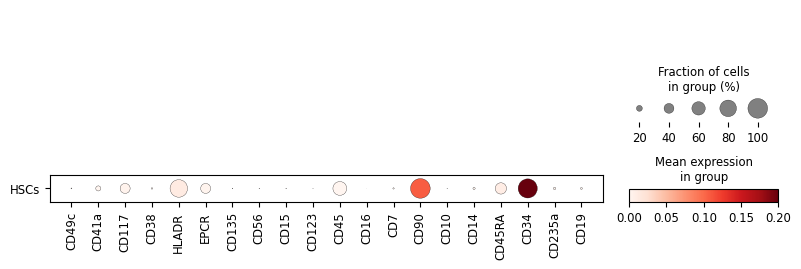

In [30]:
sc.pl.dotplot(
    adata_hsc_loop1,
    adata_hsc_loop1.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

## Get HSCs from Loop 2 Data.

### Subset Data.

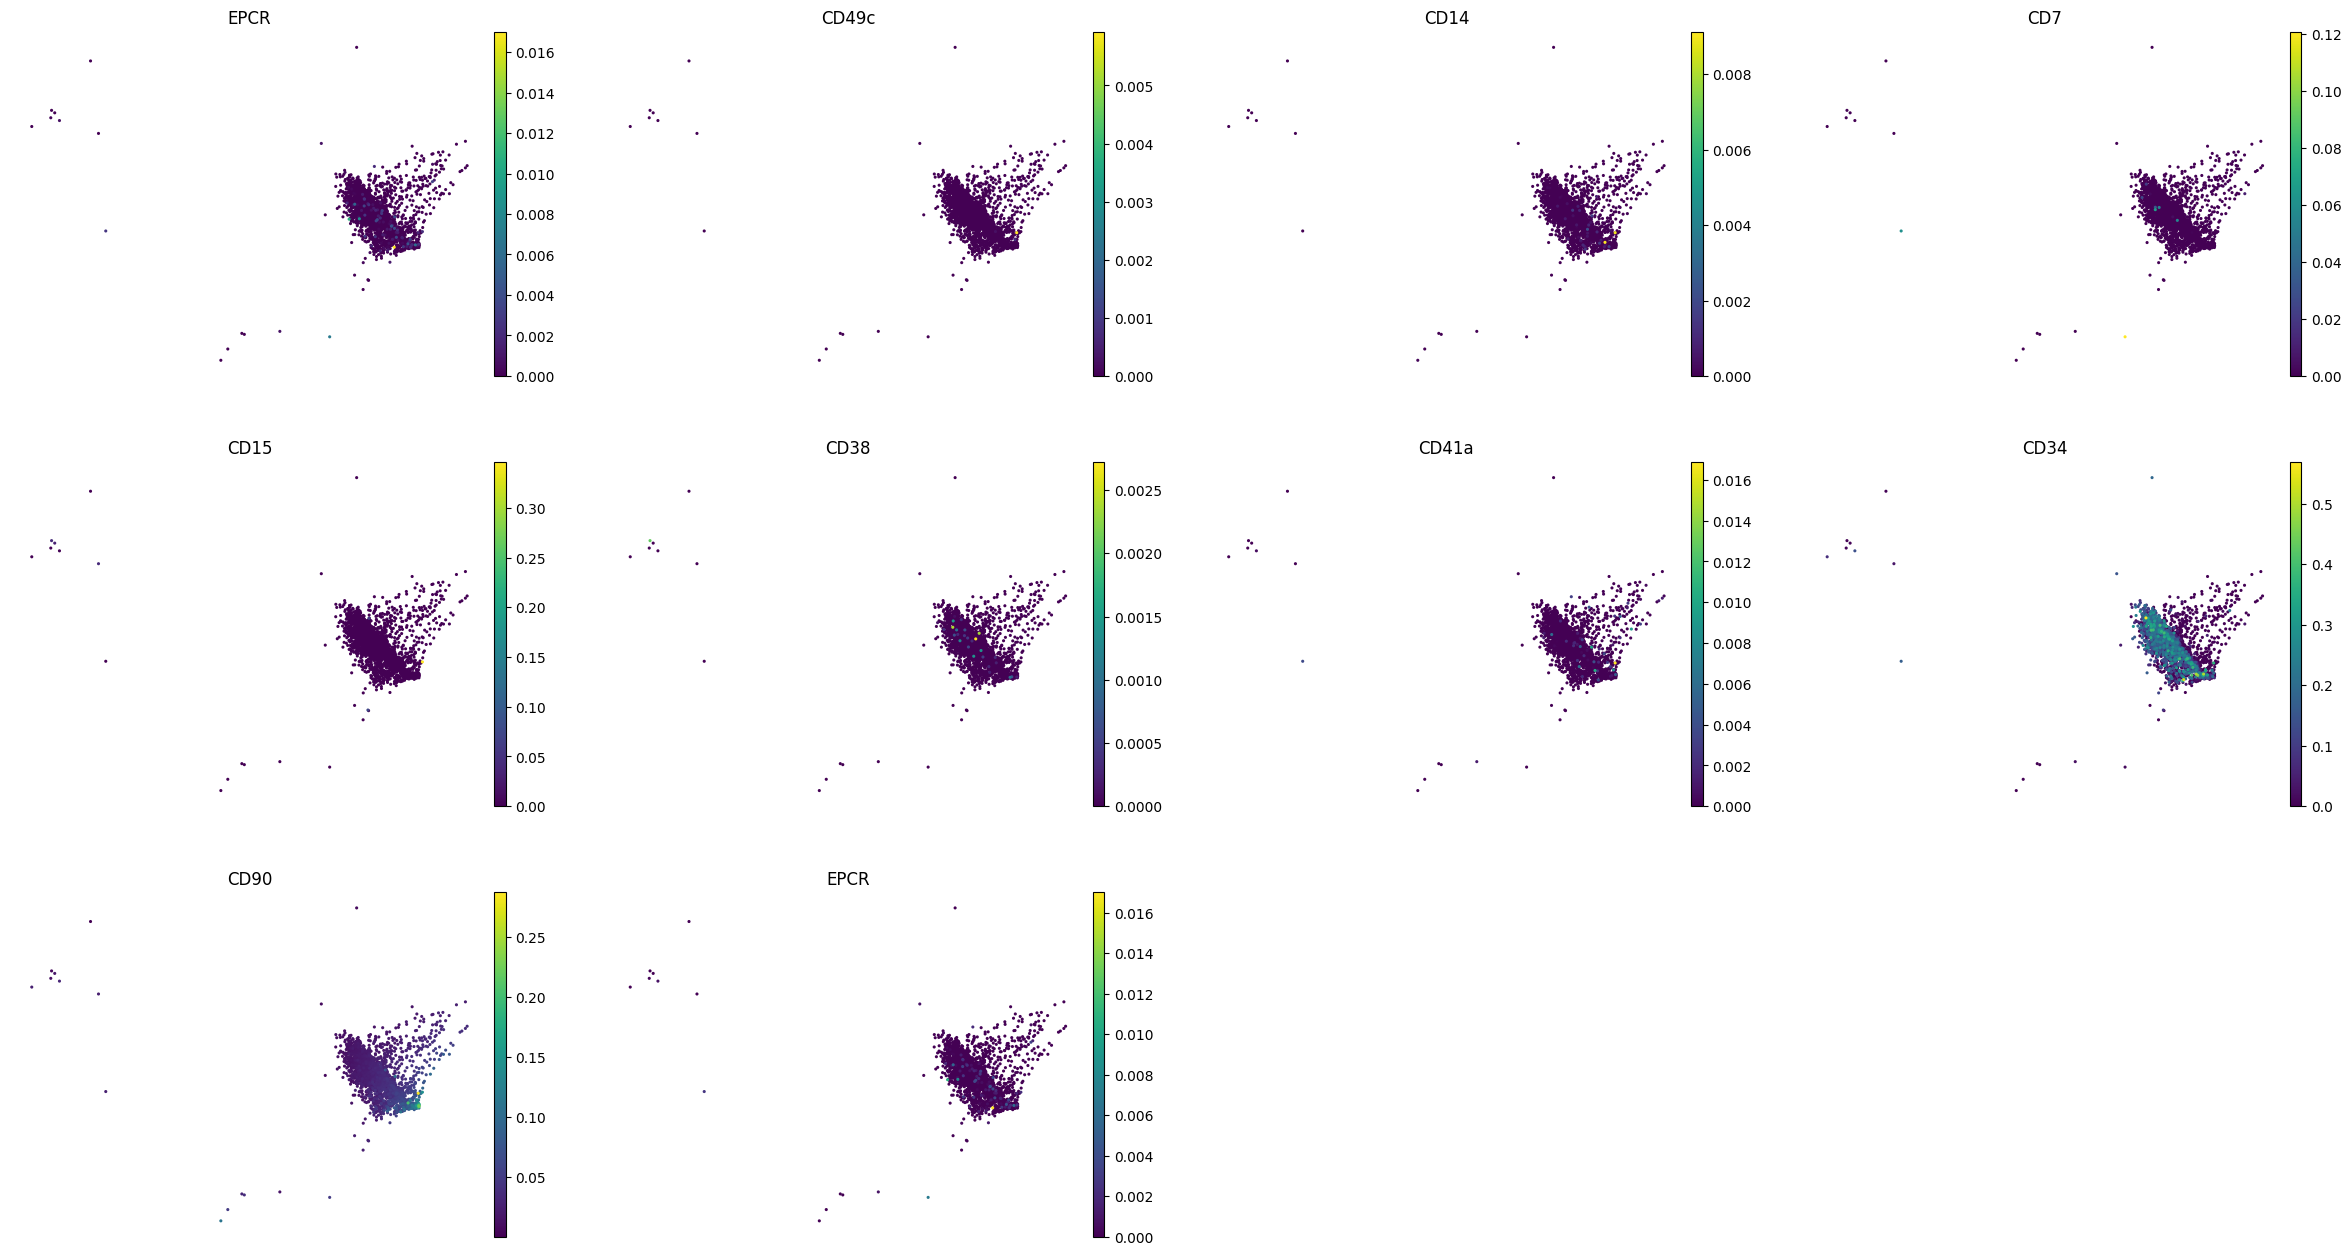

AnnData object with n_obs × n_vars = 2827 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'c

In [31]:
hsc_mask_loop2 = adata_loop2.obs["cell_type"] == "HSCs"
adata_hsc_loop2 = adata_loop2[hsc_mask_loop2].copy()
sc.pl.embedding(adata_hsc_loop2, "umap", color=dc1_markers + mgk_markers + hsc_markers, frameon=False, legend_loc="on data", s=20)
adata_hsc_loop2

### Scatter Plot Markers.

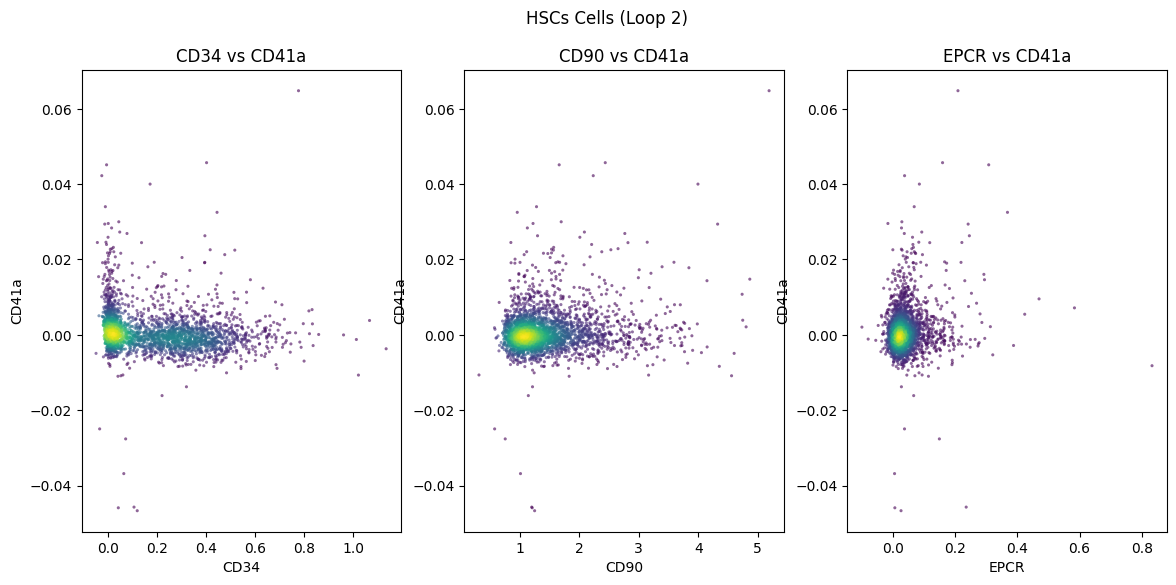

In [32]:
# plot old data
_ = make_scatter_plot(
    adata_hsc_loop2,
    target_markers=mgk_markers,
    ref_markers=hsc_markers,
    title="HSCs Cells (Loop 2)"
)

### Dotplot.

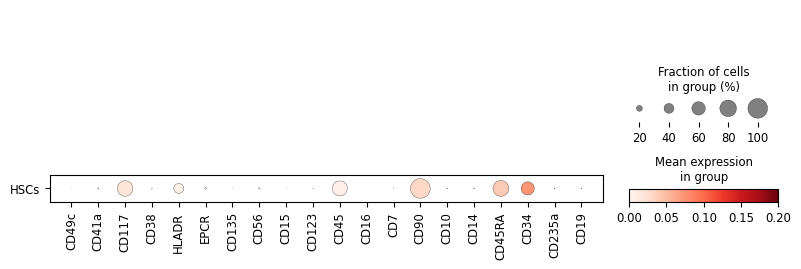

In [33]:
sc.pl.dotplot(
    adata_hsc_loop2,
    adata_hsc_loop2.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

# Reannotate DC1 Cells. 

## Leiden Clustering on pre-cDC1 (Loop 2).

### Compute Neighborhood Graph.

In [34]:
# neighbors
if "neighbors" not in adata_dc1_loop2.uns.keys():
    sc.pp.neighbors(adata_dc1_loop2)
if "neighbors_100" not in adata_dc1_loop2.uns.keys():
    sc.pp.neighbors(adata_dc1_loop2, n_neighbors=100, key_added="neighbors_100")


### Leiden Cluster with Default Neighbors.

In [35]:
# leiden with default neighbors
if "leiden" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2)
if "leiden_0.75" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_0.75")
if "leiden_0.5" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.5, key_added="leiden_0.5")
if "leiden_0.1" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.1, key_added="leiden_0.1")

/tmp/ipykernel_2468816/3521102535.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2)
/tmp/ipykernel_2468816/3521102535.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_0.75")
/tm

### Leiden Clustering with 100 Neighbors (Coarse Clustering).

In [36]:
# leiden with 100 neighbors
if "leiden_n100" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, key_added="leiden_n100", neighbors_key="neighbors_100")
if "leiden_n100_0.75" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_n100_0.75", neighbors_key="neighbors_100")
if "leiden_n100_0.5" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.5, key_added="leiden_n100_0.5", neighbors_key="neighbors_100")
if "leiden_n100_0.1" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.1, key_added="leiden_n100_0.1", neighbors_key="neighbors_100")


/tmp/ipykernel_2468816/3878321603.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2, key_added="leiden_n100", neighbors_key="neighbors_100")
/tmp/ipykernel_2468816/3878321603.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_d

### Visualize Resulting Clusters on UMAP Space.

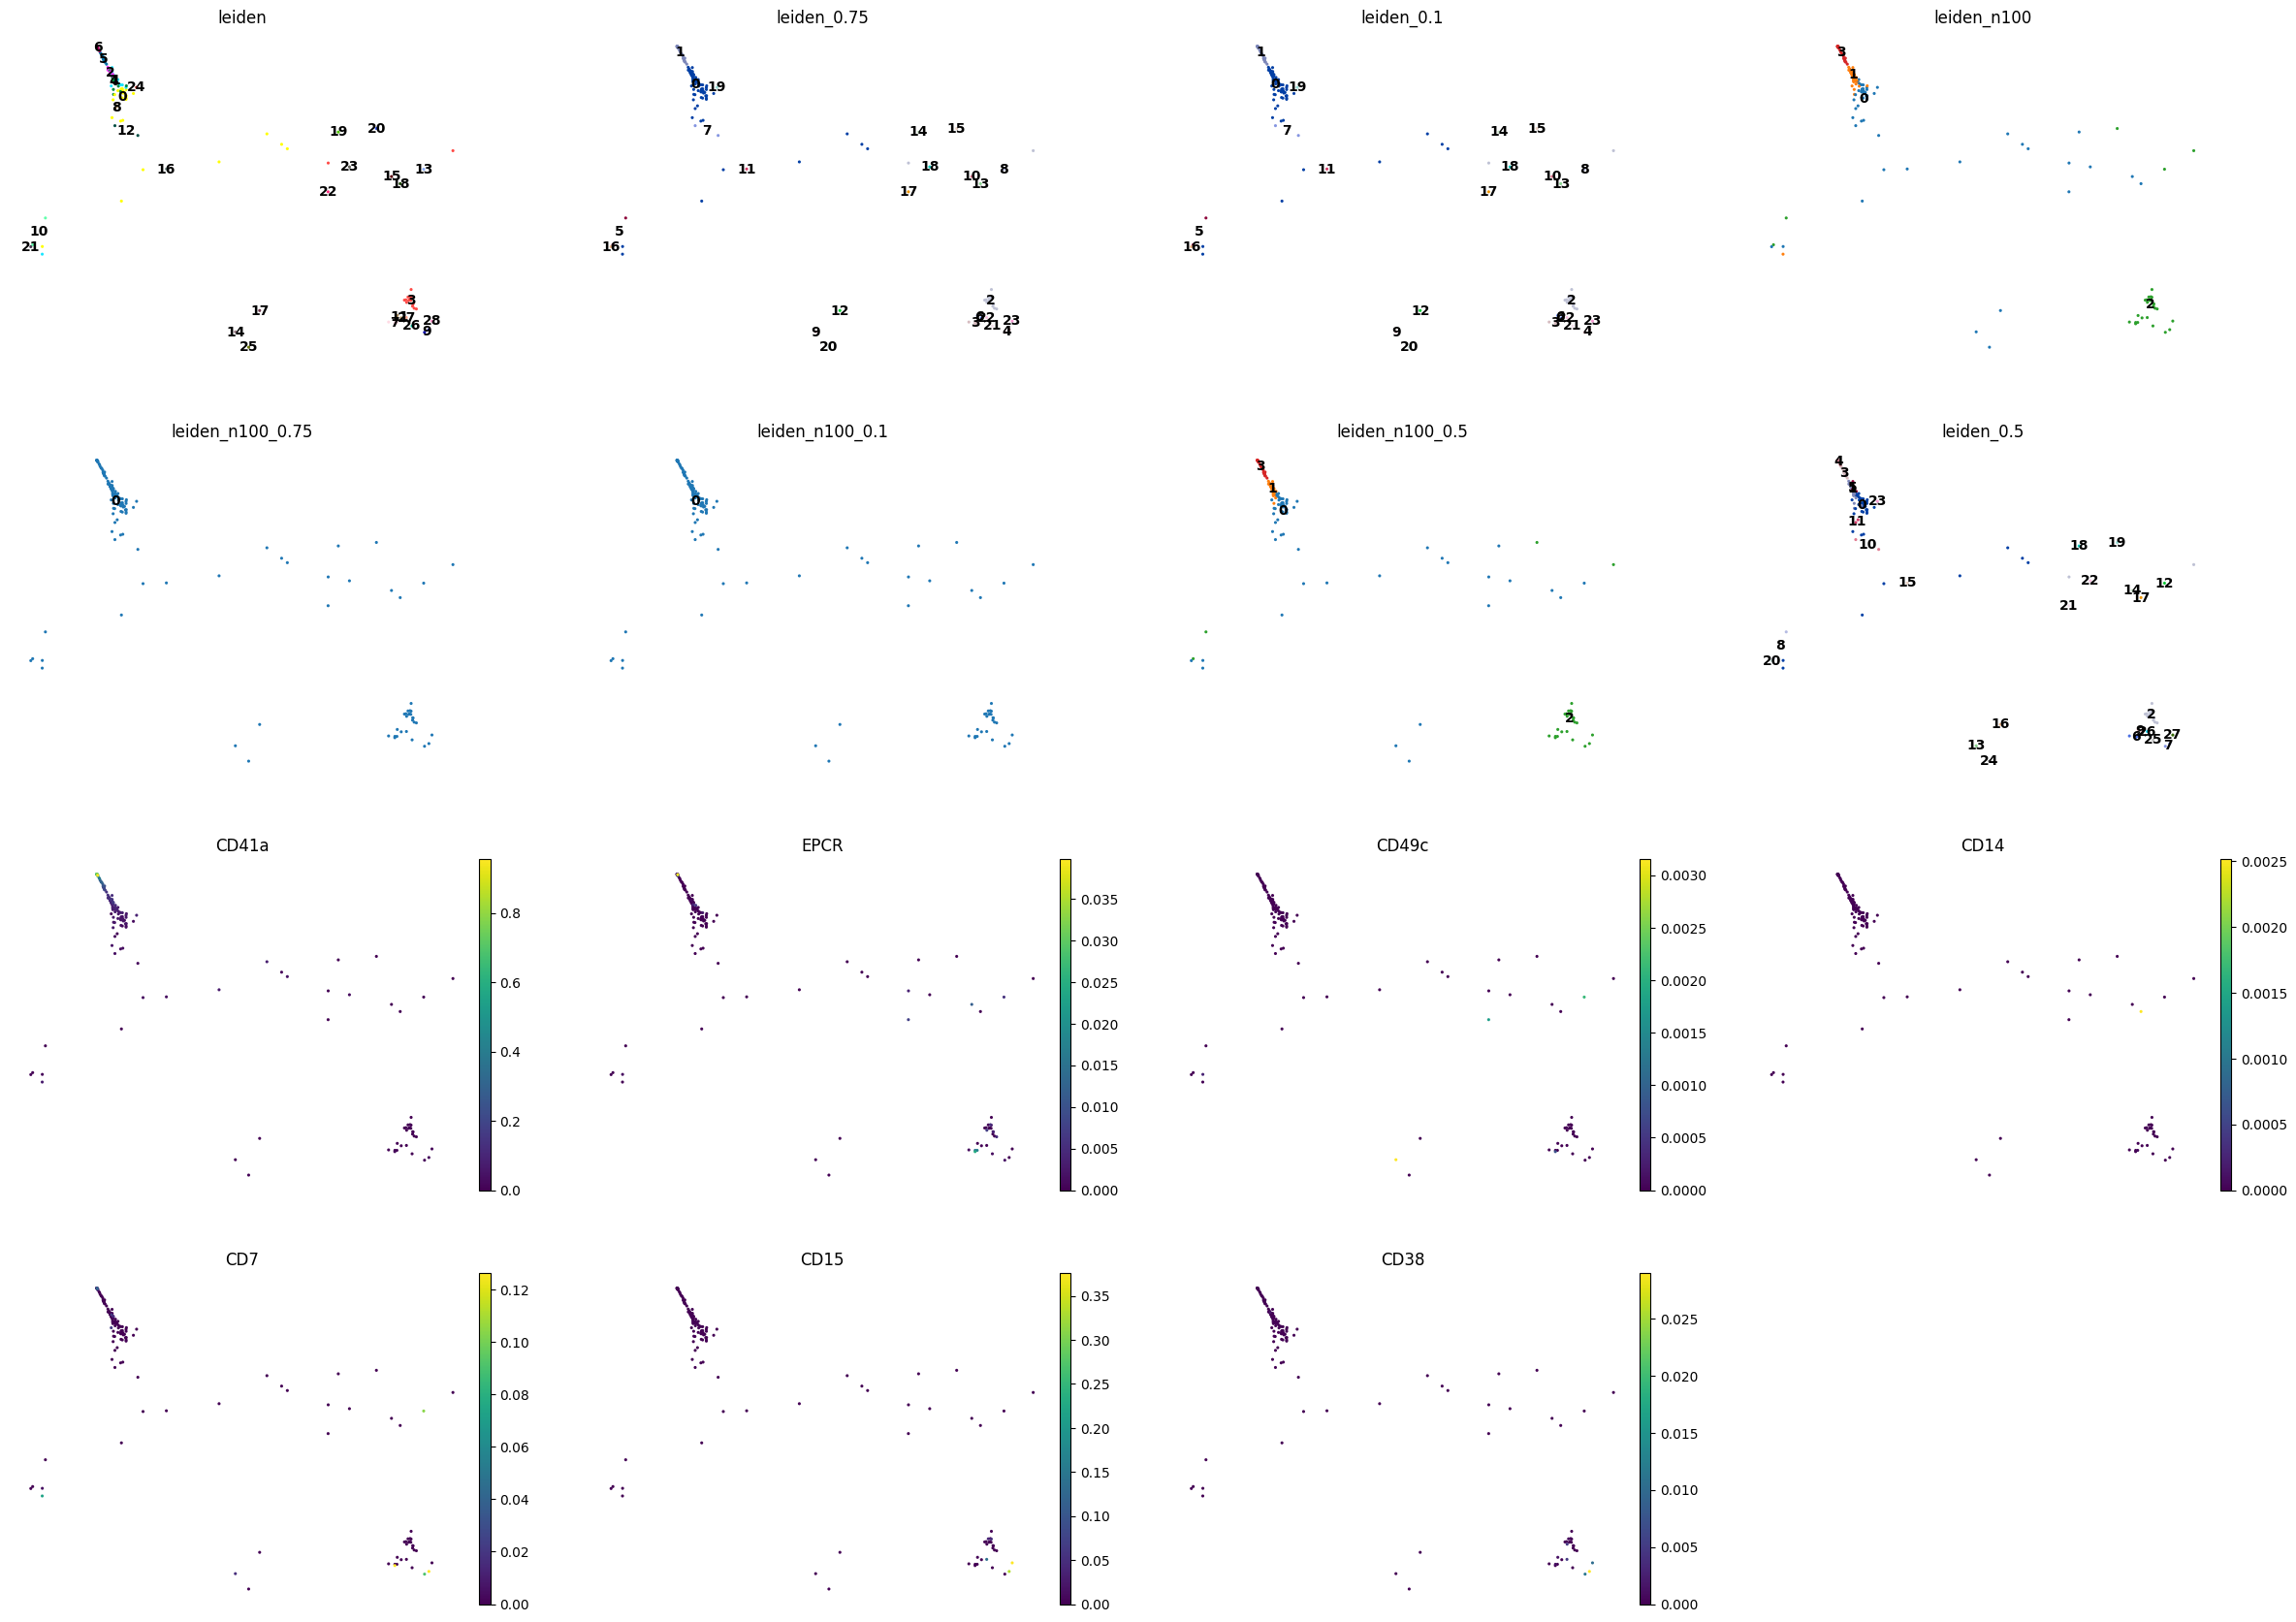

AnnData object with n_obs × n_vars = 162 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden', 'leiden_0.75', 'leiden_0.5', 'leiden_0.1', 'leiden_n100', 'leiden_n100_0.75', 'leiden_n100_0.5', 'leiden_n100_0.1'
    var: 'n', 'channel',

In [37]:
color = [
    "leiden", "leiden_0.75", "leiden_0.1", 
    "leiden_n100", "leiden_n100_0.75", "leiden_n100_0.1",
    "leiden_n100_0.5", "leiden_0.5",
]
sc.pl.embedding(adata_dc1_loop2, "umap", color=color + mgk_markers + dc1_markers, frameon=False, legend_loc="on data", s=20)
adata_dc1_loop2

### Dotplot per Leiden Clustering.

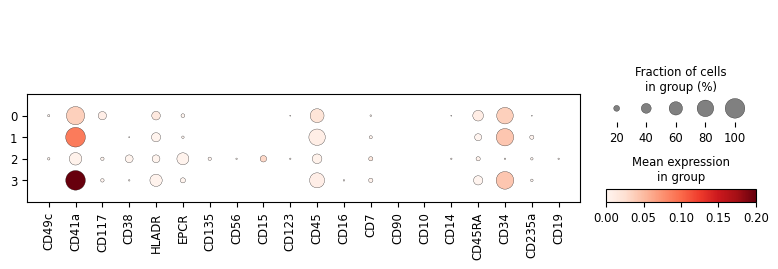

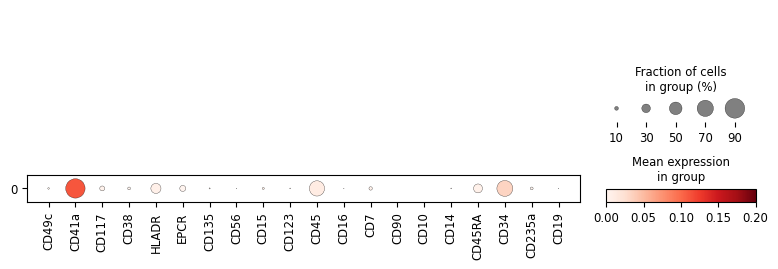

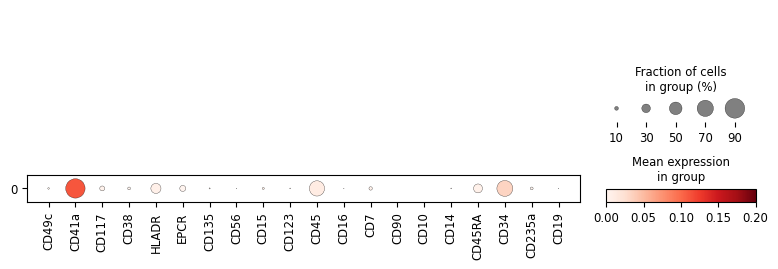

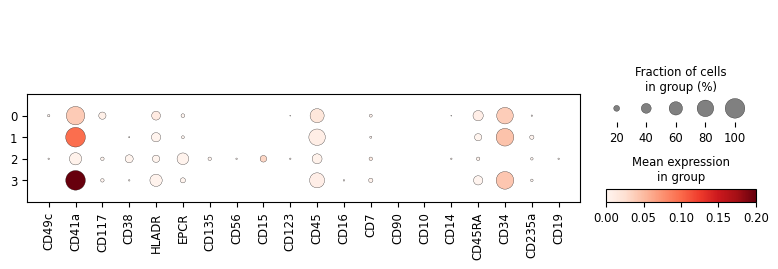

In [38]:
leiden_settings_for_dotplot = [
    "leiden_n100", "leiden_n100_0.75",
    "leiden_n100_0.1", "leiden_n100_0.5", 
]
for leiden_col in leiden_settings_for_dotplot:
    sc.pl.dotplot(
        adata_dc1_loop2,
        adata_dc1_loop2.var_names,
        leiden_col,
        vmin=0.0,
        vmax=0.2
    )


### Reannotate DC1 Cells.

... storing 'leiden_cDC1' as categorical


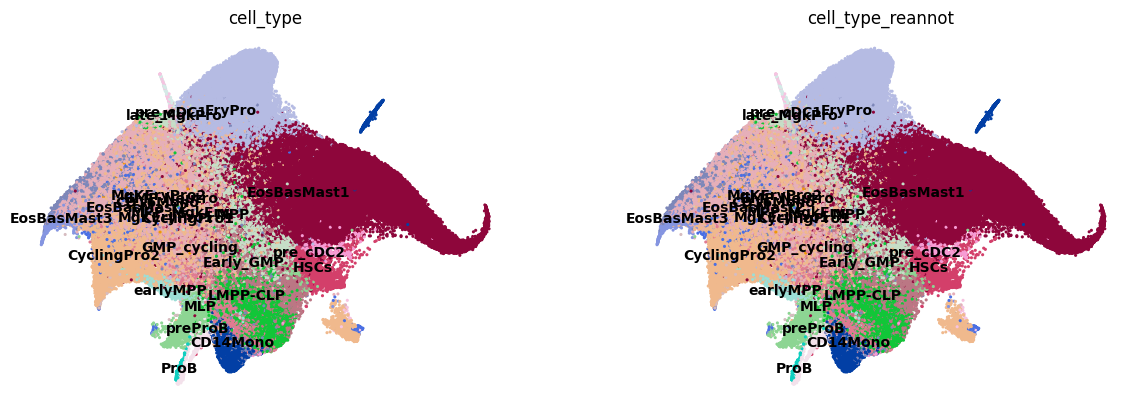

AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden_cDC1', 'cell_type_reannot', 'is_cDC1_reannot'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
   

In [39]:
reannot_col = "leiden_n100_0.1"
reannot_mapped_col = "leiden_cDC1"
reannot_val = "1"
target_ct = "late_MgkPro"
ct_col = "cell_type"
ct_col_reannot = "cell_type_reannot"
is_reannot_col = "is_cDC1_reannot"

leiden_new = np.full(adata_loop2.shape[0], None, dtype=object)
leiden_new[dc1_mask_loop2] = adata_dc1_loop2.obs[reannot_col]
adata_loop2.obs[reannot_mapped_col] = leiden_new

cell_type_reannot = adata_loop2.obs[ct_col].copy()
hsc_loop2_to_reannot = adata_loop2.obs[reannot_mapped_col] == reannot_val

if target_ct not in cell_type_reannot.cat.categories:
    cell_type_reannot = cell_type_reannot.cat.add_categories([target_ct])
cell_type_reannot[hsc_loop2_to_reannot] = target_ct

adata_loop2.obs[ct_col_reannot] = cell_type_reannot
adata_loop2.obs[is_reannot_col] = hsc_loop2_to_reannot

sc.pl.embedding(adata_loop2, "umap", color=[ct_col, ct_col_reannot], frameon=False, legend_loc="on data", s=20)
adata_loop2

# Reannotate HSCs Cells.

## Leiden Clustering on HSCs Cells (Loop 2).

### Compute Neighbor Graph.

In [40]:
# neighbors
if "neighbors" not in adata_hsc_loop2.uns.keys():
    sc.pp.neighbors(adata_hsc_loop2)
if "neighbors_100" not in adata_hsc_loop2.uns.keys():
    sc.pp.neighbors(adata_hsc_loop2, n_neighbors=100, key_added="neighbors_100")


### Run Leiden Clustering with Default Neighbors.

In [41]:
# leiden with default neighbors
if "leiden" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2)
if "leiden_0.75" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, resolution=0.075, key_added="leiden_0.75")
if "leiden_0.5" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, resolution=0.5, key_added="leiden_0.5")
if "leiden_0.1" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, resolution=0.1, key_added="leiden_0.1")

/tmp/ipykernel_2468816/3475631987.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hsc_loop2)
/tmp/ipykernel_2468816/3475631987.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hsc_loop2, resolution=0.075, key_added="leiden_0.75")
/tm

### Run Leiden Clustering with 100 Neighbors (Coarse Clustering).

In [42]:
# leiden with 100 neighbors
if "leiden_n100" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, key_added="leiden_n100", neighbors_key="neighbors_100")
if "leiden_n100_0.75" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, resolution=0.075, key_added="leiden_n100_0.75", neighbors_key="neighbors_100")
if "leiden_n100_0.5" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, resolution=0.5, key_added="leiden_n100_0.5", neighbors_key="neighbors_100")
if "leiden_n100_0.1" not in adata_hsc_loop2.obs.columns:
    sc.tl.leiden(adata_hsc_loop2, resolution=0.1, key_added="leiden_n100_0.1", neighbors_key="neighbors_100")
adata_hsc_loop2

/tmp/ipykernel_2468816/1687403060.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hsc_loop2, key_added="leiden_n100", neighbors_key="neighbors_100")
/tmp/ipykernel_2468816/1687403060.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_h

AnnData object with n_obs × n_vars = 2827 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden', 'leiden_0.75', 'leiden_0.5', 'leiden_0.1', 'leiden_n100', 'leiden_n100_0.75', 'leiden_n100_0.5', 'leiden_n100_0.1'
    var: 'n', 'channel'

### Visualize Resulting Clusters Vin UMAP Space.

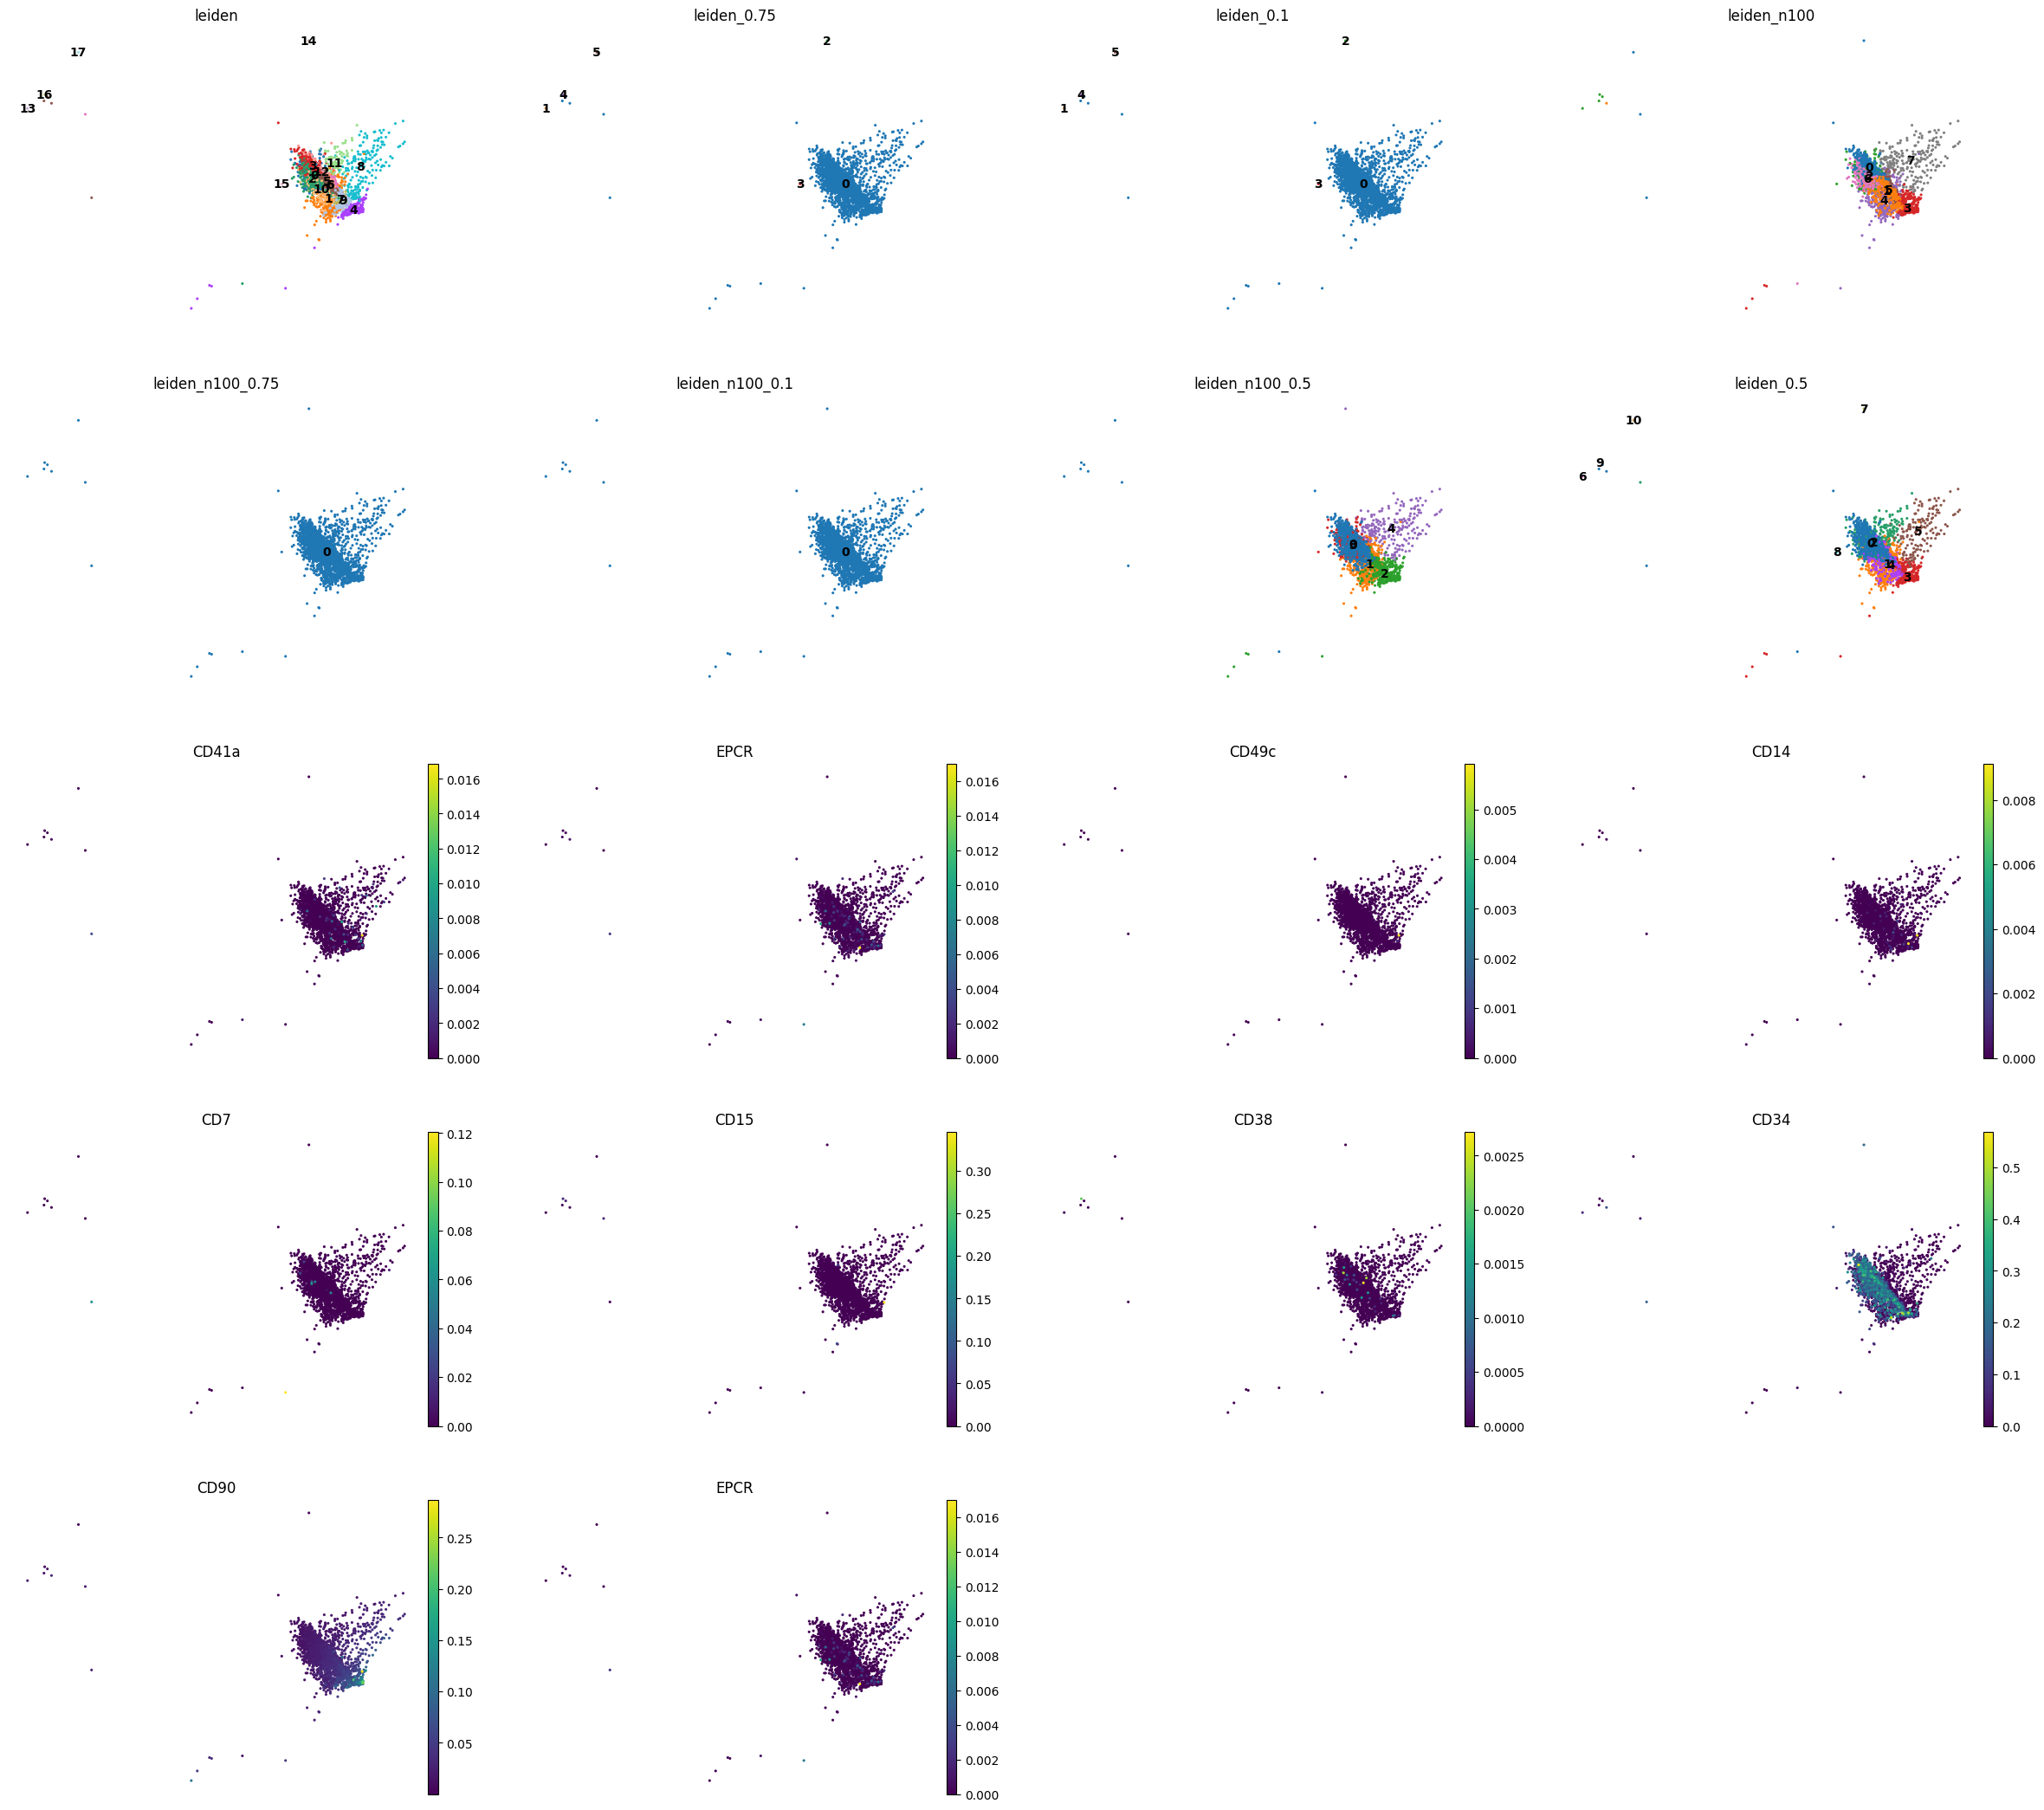

AnnData object with n_obs × n_vars = 2827 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden', 'leiden_0.75', 'leiden_0.5', 'leiden_0.1', 'leiden_n100', 'leiden_n100_0.75', 'leiden_n100_0.5', 'leiden_n100_0.1'
    var: 'n', 'channel'

In [43]:
color = [
    "leiden", "leiden_0.75", "leiden_0.1", 
    "leiden_n100", "leiden_n100_0.75", "leiden_n100_0.1",
    "leiden_n100_0.5", "leiden_0.5",
]
sc.pl.embedding(adata_hsc_loop2, "umap", color=color + mgk_markers + dc1_markers + hsc_markers, frameon=False, legend_loc="on data", s=20)
adata_hsc_loop2

### Dotplot per Leiden Clustering.

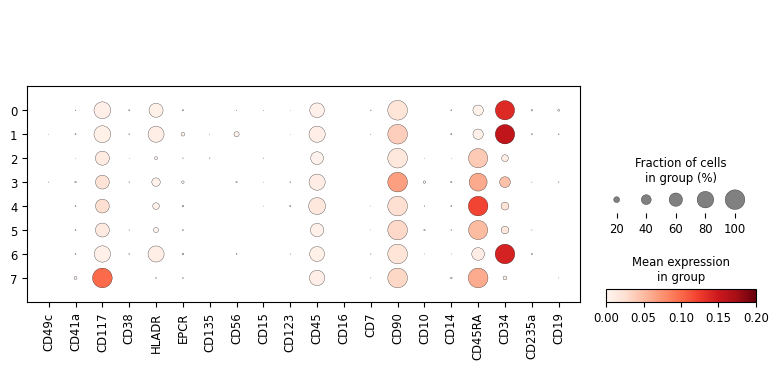

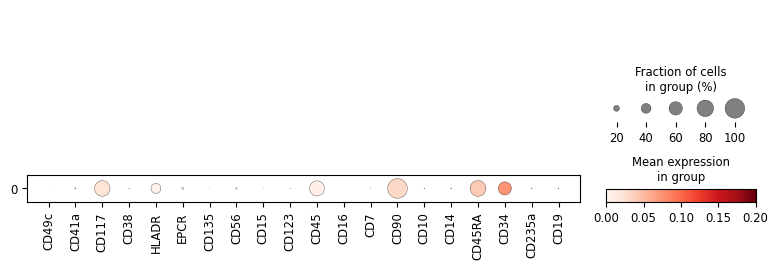

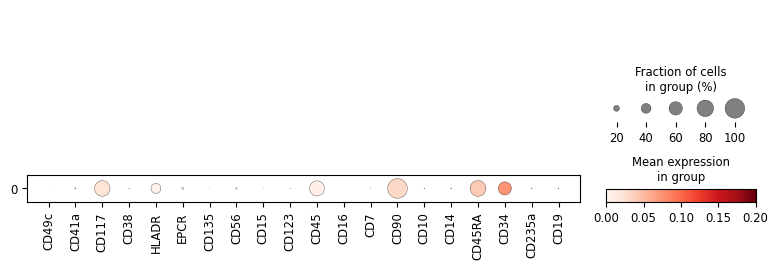

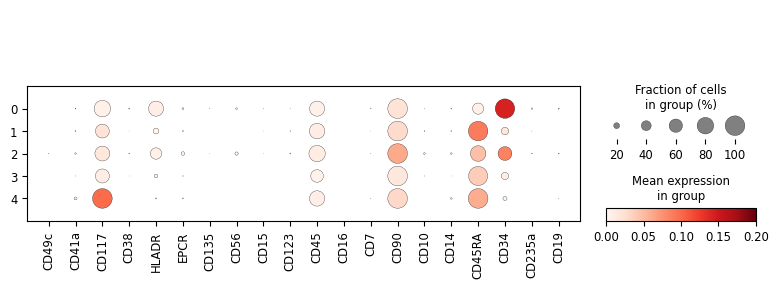

In [44]:
leiden_settings_for_dotplot = [
    "leiden_n100", "leiden_n100_0.75",
    "leiden_n100_0.1", "leiden_n100_0.5", 
]
for leiden_col in leiden_settings_for_dotplot:
    sc.pl.dotplot(
        adata_hsc_loop2,
        adata_hsc_loop2.var_names,
        leiden_col,
        vmin=0.0,
        vmax=0.2
    )


### Get Indices of Cells to Reannotate.

... storing 'leiden_HSCs' as categorical


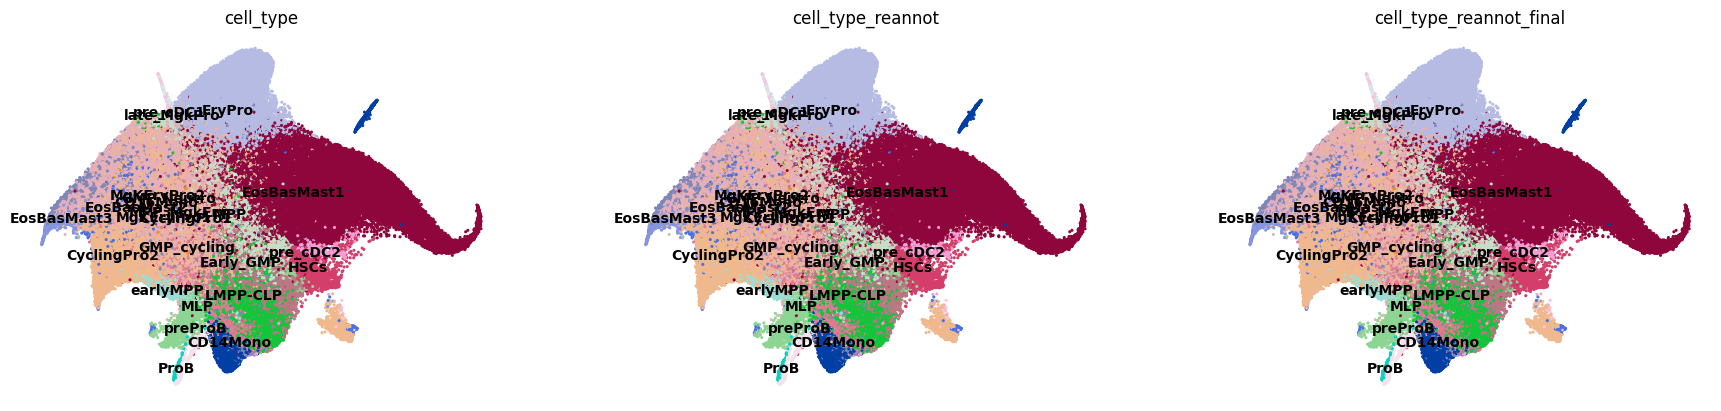

AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden_cDC1', 'cell_type_reannot', 'is_cDC1_reannot', 'leiden_HSCs', 'cell_type_reannot_final', 'is_HSCs_reannot'
    var: 'n', 'channel', 'marke

In [45]:
reannot_col = "leiden_n100_0.75"
reannot_mapped_col = "leiden_HSCs"
reannot_val = "1"
target_ct = "late_MgkPro"
ct_col = "cell_type_reannot"
ct_col_reannot = "cell_type_reannot_final"
is_reannot_col = "is_HSCs_reannot"

leiden_new = np.full(adata_loop2.shape[0], None, dtype=object)
leiden_new[hsc_mask_loop2] = adata_hsc_loop2.obs[reannot_col]
adata_loop2.obs[reannot_mapped_col] = leiden_new

cell_type_reannot = adata_loop2.obs[ct_col].copy()
hsc_loop2_to_reannot = adata_loop2.obs[reannot_mapped_col] == reannot_val

if target_ct not in cell_type_reannot.cat.categories:
    cell_type_reannot = cell_type_reannot.cat.add_categories([target_ct])
cell_type_reannot[hsc_loop2_to_reannot] = target_ct

adata_loop2.obs[ct_col_reannot] = cell_type_reannot
adata_loop2.obs[is_reannot_col] = hsc_loop2_to_reannot

sc.pl.embedding(adata_loop2, "umap", color=["cell_type", ct_col, ct_col_reannot], frameon=False, legend_loc="on data", s=20)
adata_loop2

# Write Data to Disk.

## Save Residual Data from Loop 2.

### Write to disk.

In [46]:
write_out = False

reannot_out_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/replicate/reannot"
h5ad_500k_res_out_path = os.path.join(reannot_out_dir, "adata_500k_residual.h5ad")
adata_loop2_cleaned = sanitize_anndata(adata_loop2)

if write_out:
    adata_loop2_cleaned.write_h5ad(h5ad_500k_res_out_path)
adata_loop2_cleaned

AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden_cDC1', 'cell_type_reannot', 'is_cDC1_reannot', 'leiden_HSCs', 'cell_type_reannot_final', 'is_HSCs_reannot'
    var: 'n', 'channel', 'marke

## Save Concatenated Data.

### Prepare Extra Columns.

In [47]:
loop1_ct_values = adata_loop1.obs["cell_type"].copy()
mapped_extra_cols = {
    'leiden_HSCs': None,
    'cell_type_reannot': loop1_ct_values,
    'is_cDC1_reannot': False,
    'cell_type_reannot_final': loop1_ct_values,
    'is_HSCs_reannot': False,
    'leiden_cDC1': None
}

for col_name, col_val in mapped_extra_cols.items():
    adata_loop1.obs[col_name] = col_val
adata_loop1

AnnData object with n_obs × n_vars = 499956 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type', 'leiden_HSCs', 'cell_type_reannot', 'is_cDC1_reannot', 'cell_type_reannot_final', 'is_HSCs_reannot', 'leiden_cDC1'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 

### Concatenate Residual Data with Loop 1 Data.

In [48]:
adata_concat = sc.concat((adata_loop1, adata_loop2), merge="same", uns_merge="same")
adata_concat.obs_names_make_unique()
adata_concat

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/merge.py:1675: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/merge.py:1675: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.

AnnData object with n_obs × n_vars = 999952 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden_HSCs', 'cell_type_reannot', 'is_cDC1_reannot', 'cell_type_reannot_final', 'is_HSCs_reannot', 'leiden_cDC1'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody

### Write to Disk.

In [49]:
h5ad_500k_concat_out_path = os.path.join(reannot_out_dir, "adata_500k.h5ad")
adata_concat = sanitize_anndata(adata_concat)
if write_out:
    adata_concat.write_h5ad(h5ad_500k_concat_out_path)
adata_concat

AnnData object with n_obs × n_vars = 999952 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden_HSCs', 'cell_type_reannot', 'is_cDC1_reannot', 'cell_type_reannot_final', 'is_HSCs_reannot', 'leiden_cDC1'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody